In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import pyarrow
import xlrd


In [3]:


df = pd.read_excel("files/GSE63577_counts_rpkm_exvivo_jenage_data.xls",engine="xlrd")
df


,ensembl_gene_id,external_gene_id,description,gene_biotype,BJ_Y1,BJ_Y2,BJ_Y3,BJ_OLD_1,BJ_OLD_2,BJ_OLD_3,...,HFF_PD16_3,HFF_PD74_1,HFF_PD74_2,HFF_PD74_3,MRC_5_PD32_1,MRC_5_PD32_2,MRC_5_PD32_3,MRC_5_PD72_1,MRC_5_PD72_2,MRC_5_PD72_3
0,ENSG00000000003,TSPAN6,tetraspanin 6 [Source:HGNC Symbol;Acc:11858],protein_coding,521,755,890,766,1155,907,...,659,1763,1324,1416,990,1062,1272,1360,1444,1580
1,ENSG00000000005,TNMD,tenomodulin [Source:HGNC Symbol;Acc:17757],protein_coding,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,ENSG00000000419,DPM1,dolichyl-phosphate mannosyltransferase polypep...,protein_coding,791,972,1240,701,1159,858,...,1159,1113,873,950,1033,1092,1204,986,962,1026
3,ENSG00000000457,SCYL3,SCY1-like 3 (S. cerevisiae) [Source:HGNC Symbo...,protein_coding,251,350,393,203,377,265,...,254,259,214,257,217,261,261,297,268,266
4,ENSG00000000460,C1orf112,chromosome 1 open reading frame 112 [Source:HG...,protein_coding,339,482,584,162,272,206,...,301,111,93,107,184,233,228,142,120,115
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
56294,ENSG00000261838,RP11-303E16.6,NaN,antisense,0,0,1,0,2,1,...,1,0,0,0,3,0,2,1,1,0
56295,ENSG00000261839,RP1-265C24.8,NaN,lincRNA,2,5,3,2,6,6,...,7,6,1,8,3,3,4,5,7,2
56296,ENSG00000261840,RP11-146F11.1,NaN,antisense,9,11,25,6,10,17,...,18,6,8,12,11,10,10,9,16,15
56297,ENSG00000261841,RP11-928F19.5,NaN,lincRNA,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


بخش اول: شناخت اولیه دیتاست و کیفیت داده‌ها

سؤال 1

چند سطر و ستون در دیتاست وجود دارد؟

هدف: شناخت ابعاد دیتاست و درک حجم داده‌ها

In [4]:
df.shape

(56299, 34)

سؤال 2

نام و معنی تمام ستون‌های دیتاست چیست؟
درباره ی هرکدوم از ستون ها تحقیق و اطلاعات ازشون بدست آورید
هدف: آشنایی با ساختار کلی دیتاست و شناسایی ستون‌های اطلاعاتی و ستون‌های نمونه‌ها

ensembl_gene_id
<br>
شناسه یکتای هر ژن در پایگاه داده Ensembl
<br>
<br>
external_gene_id
<br>
نام استاندارد ژن
<br>
<br>
description
<br>
توضیح یا شرح عملکرد ژن
<br>
<br>
gene_biotype
<br>
نوع ژن
<br>
<br>
BJ_Y1
<br>
نمونه اول از سلول فیبروبلاست BJ در حالت جوان 
<br>
<br>
BJ_Y2
<br>
نمونه دوم از سلول فیبروبلاست BJ در حالت جوان
<br>
<br>
BJ_Y3
<br>
نمونه سوم از سلول فیبروبلاست BJ در حالت جوان
<br>
<br>
BJ_OLD_1
<br>
نمونه اول از سلول فیبروبلاست BJ در حالت پیر
<br>
<br>
BJ_OLD_2
<br>
نمونه دوم از سلول فیبروبلاست BJ در حالت پیر
<br>
<br>
BJ_OLD_3
<br>
نمونه سوم از سلول فیبروبلاست BJ در حالت پیر
<br>
<br>
IMR90_Y1
<br>
نمونه اول از سلول فیبروبلاست ریه IMR90 در حالت جوان
<br>
<br>
IMR90_Y2
<br>
نمونه دوم از سلول IMR90 در حالت جوان
<br>
<br>
IMR90_Y3
<br>
نمونه سوم از سلول IMR90 در حالت جوان
<br>
<br>
IMR90_O1
<br>
نمونه اول از سلول IMR90 در حالت پیر
<br>
<br>
IMR90_O2
<br>
نمونه دوم از سلول IMR90 در حالت پیر
<br>
<br>
IMR90_O3
<br>
نمونه سوم از سلول IMR90 در حالت پیر
<br>
<br>
WI_38_Y1
<br>
نمونه اول از سلول WI-38 در حالت جوان
<br>
<br>
WI_38_Y2
<br>
نمونه دوم از سلول WI-38 در حالت جوان
<br>
<br>
WI_38_Y3
<br>
نمونه سوم از سلول WI-38 در حالت جوان
<br>
<br>
WI_38_O1
<br>
نمونه اول از سلول WI-38 در حالت پیر
<br>
<br>
WI_38_O2
<br>
نمونه دوم از سلول WI-38 در حالت پیر
<br>
<br>
WI_38_O3
<br>
نمونه سوم از سلول WI-38 در حالت پیر
<br>
<br>
HFF_PD16_1
<br>
نمونه اول از سلول HFF پس از 16 بار تقسیم سلولی (جوان)
<br>
<br>
HFF_PD16_2
<br>
نمونه دوم از سلول HFF جوان
<br>
<br>
HFF_PD16_3
<br>
نمونه سوم از سلول HFF جوان
<br>
<br>
HFF_PD74_1
<br>
نمونه اول از سلول HFF پس از 74 بار تقسیم سلولی (پیر)
<br>
<br>
HFF_PD74_2
<br>
نمونه دوم از سلول HFF پیر
<br>
<br>
HFF_PD74_3
<br>
نمونه سوم از سلول HFF پیر
<br>
<br>
MRC_5_PD32_1
<br>
نمونه اول از سلول MRC-5 پس از 32 بار تقسیم سلولی (جوان‌تر)
<br>
<br>
MRC_5_PD32_2
<br>
نمونه دوم از سلول MRC-5 جوان‌تر
<br>
<br>
MRC_5_PD32_3
<br>
نمونه سوم از سلول MRC-5 جوان‌تر
<br>
<br>
MRC_5_PD72_1
<br>
نمونه اول از سلول MRC-5 پس از 72 بار تقسیم سلولی (پیرتر)
<br>
<br>
MRC_5_PD72_2
<br>
نمونه دوم از سلول MRC-5 پیرتر
<br>
<br>
MRC_5_PD72_3
<br>
نمونه سوم از سلول MRC-5 پیرتر
<br>

In [5]:
df.columns

Index(['ensembl_gene_id', 'external_gene_id', 'description', 'gene_biotype',
       'BJ_Y1', 'BJ_Y2', 'BJ_Y3', 'BJ_OLD_1', 'BJ_OLD_2', 'BJ_OLD_3',
       'IMR90_Y1', 'IMR90_Y2', 'IMR90_Y3', 'IMR90_O1', 'IMR90_O2', 'IMR90_O3',
       'WI_38_Y1', 'WI_38_Y2', 'WI_38_Y3', 'WI_38_O1', 'WI_38_O2', 'WI_38_O3',
       'HFF_PD16_1', 'HFF_PD16_2', 'HFF_PD16_3', 'HFF_PD74_1', 'HFF_PD74_2',
       'HFF_PD74_3', 'MRC_5_PD32_1', 'MRC_5_PD32_2', 'MRC_5_PD32_3',
       'MRC_5_PD72_1', 'MRC_5_PD72_2', 'MRC_5_PD72_3'],
      dtype='str')

سؤال 3

نوع داده (Data Type) هر ستون چیست؟

هدف: تشخیص ستون‌های متنی، دسته‌ای و عددی برای تحلیل‌های بعدی

In [6]:
df.dtypes

ensembl_gene_id       str
external_gene_id      str
description           str
gene_biotype          str
BJ_Y1               int64
BJ_Y2               int64
BJ_Y3               int64
BJ_OLD_1            int64
BJ_OLD_2            int64
BJ_OLD_3            int64
IMR90_Y1            int64
IMR90_Y2            int64
IMR90_Y3            int64
IMR90_O1            int64
IMR90_O2            int64
IMR90_O3            int64
WI_38_Y1            int64
WI_38_Y2            int64
WI_38_Y3            int64
WI_38_O1            int64
WI_38_O2            int64
WI_38_O3            int64
HFF_PD16_1          int64
HFF_PD16_2          int64
HFF_PD16_3          int64
HFF_PD74_1          int64
HFF_PD74_2          int64
HFF_PD74_3          int64
MRC_5_PD32_1        int64
MRC_5_PD32_2        int64
MRC_5_PD32_3        int64
MRC_5_PD72_1        int64
MRC_5_PD72_2        int64
MRC_5_PD72_3        int64
dtype: object

سؤال 4: هر ستون را از نظر نوع متغیر دسته‌بندی کنید

متنی (Text)

دسته‌ای (Categorical)

عددی (Numerical)

هدف: درک نقش هر ستون در تحلیل داده

متنی:

ensembl_gene_id

external_gene_id

description
<br>
<br>
<br>
<br>
دسته ای:

gene_biotype
<br>
<br>
<br>
<br>
عددی:

BJ_Y1

BJ_Y2

BJ_Y3

BJ_OLD_1

BJ_OLD_2

BJ_OLD_3

IMR90_Y1

IMR90_Y2

IMR90_Y3

IMR90_O1

IMR90_O2

IMR90_O3

WI_38_Y1

WI_38_Y2

WI_38_Y3

WI_38_O1

WI_38_O2

WI_38_O3

HFF_PD16_1

HFF_PD16_2

HFF_PD16_3

HFF_PD74_1

HFF_PD74_2

HFF_PD74_3

MRC_5_PD32_1

MRC_5_PD32_2

MRC_5_PD32_3

MRC_5_PD72_1

MRC_5_PD72_2

MRC_5_PD72_3

سؤال 5: در هر ستون چند مقدار Null وجود دارد؟

هدف: ارزیابی اولیه کیفیت داده‌ها.

In [7]:
# print((df.isnull().sum()) / len(df.columns))
df.isnull().sum()

ensembl_gene_id         0
external_gene_id     1777
description         21372
gene_biotype         1777
BJ_Y1                   0
BJ_Y2                   0
BJ_Y3                   0
BJ_OLD_1                0
BJ_OLD_2                0
BJ_OLD_3                0
IMR90_Y1                0
IMR90_Y2                0
IMR90_Y3                0
IMR90_O1                0
IMR90_O2                0
IMR90_O3                0
WI_38_Y1                0
WI_38_Y2                0
WI_38_Y3                0
WI_38_O1                0
WI_38_O2                0
WI_38_O3                0
HFF_PD16_1              0
HFF_PD16_2              0
HFF_PD16_3              0
HFF_PD74_1              0
HFF_PD74_2              0
HFF_PD74_3              0
MRC_5_PD32_1            0
MRC_5_PD32_2            0
MRC_5_PD32_3            0
MRC_5_PD72_1            0
MRC_5_PD72_2            0
MRC_5_PD72_3            0
dtype: int64

سؤال 6: درصد داده‌های گمشده (Missing Values) در هر ستون چقدر است؟



In [8]:
missing_percent = (df.isnull().sum() / len(df)) * 100
missing_percent.sort_values(ascending=False)

description         37.961598
external_gene_id     3.156362
gene_biotype         3.156362
ensembl_gene_id      0.000000
BJ_Y1                0.000000
BJ_Y2                0.000000
BJ_Y3                0.000000
BJ_OLD_1             0.000000
BJ_OLD_2             0.000000
BJ_OLD_3             0.000000
IMR90_Y1             0.000000
IMR90_Y2             0.000000
IMR90_Y3             0.000000
IMR90_O1             0.000000
IMR90_O2             0.000000
IMR90_O3             0.000000
WI_38_Y1             0.000000
WI_38_Y2             0.000000
WI_38_Y3             0.000000
WI_38_O1             0.000000
WI_38_O2             0.000000
WI_38_O3             0.000000
HFF_PD16_1           0.000000
HFF_PD16_2           0.000000
HFF_PD16_3           0.000000
HFF_PD74_1           0.000000
HFF_PD74_2           0.000000
HFF_PD74_3           0.000000
MRC_5_PD32_1         0.000000
MRC_5_PD32_2         0.000000
MRC_5_PD32_3         0.000000
MRC_5_PD72_1         0.000000
MRC_5_PD72_2         0.000000
MRC_5_PD72

سؤال 7: آیا رکوردهای تکراری (Duplicate Rows) در دیتاست وجود دارند؟



In [9]:
duplicate_count = df.duplicated().sum()
print(bool(duplicate_count))

False


سؤال 8: اگر رکورد تکراری وجود دارد، تعداد و درصد آن چقدر است؟

هدف: اندازه‌گیری میزان تکرار داده‌ها

In [10]:
if duplicate_count:
    print(duplicate_count)
    duplicate_percent = (duplicate_count / len(df)) * 100
    print(duplicate_percent)


بخش دوم: تحلیل ویژگی‌های متنی و دسته‌ای

سؤال 9: چند نوع مختلف ژن (gene_biotype) در دیتاست وجود دارد؟

هدف: شناخت تنوع زیستی ژن‌های موجود در دیتاست

In [11]:
print(df["gene_biotype"].nunique(dropna=False))
print(df["gene_biotype"].unique())


31
<ArrowStringArray>
[          'protein_coding',               'pseudogene',
     'processed_transcript',                  'lincRNA',
                'antisense',                        nan,
   'polymorphic_pseudogene',                'IG_V_gene',
           'sense_intronic',                'TR_V_gene',
                 'misc_RNA',                    'snRNA',
                    'miRNA',          'IG_V_pseudogene',
                   'snoRNA',                     'rRNA',
                  'Mt_tRNA',                  'Mt_rRNA',
                'IG_C_gene',                'IG_J_gene',
                'TR_J_gene',                'TR_C_gene',
          'TR_V_pseudogene',          'TR_J_pseudogene',
                'IG_D_gene',          'IG_C_pseudogene',
                'TR_D_gene',          'IG_J_pseudogene',
        'sense_overlapping', '3prime_overlapping_ncrna',
               'non_coding']
Length: 31, dtype: str


سؤال 10: فراوانی هر نوع ژن (gene_biotype) چقدر است؟

هدف: بررسی اینکه کدام نوع ژن بیشترین سهم را در دیتاست دارد.

In [12]:
biotype_counts = df["gene_biotype"].value_counts(dropna=False)
biotype_counts

gene_biotype
protein_coding              21226
pseudogene                  13444
lincRNA                      5769
antisense                    3911
snRNA                        1931
NaN                          1777
misc_RNA                     1701
miRNA                        1639
processed_transcript         1526
snoRNA                       1516
rRNA                          537
sense_intronic                478
IG_V_pseudogene               151
TR_V_gene                     150
sense_overlapping             129
IG_V_gene                     126
TR_J_gene                      82
TR_V_pseudogene                40
polymorphic_pseudogene         29
IG_D_gene                      27
3prime_overlapping_ncrna       26
Mt_tRNA                        22
IG_J_gene                      18
IG_C_gene                      14
IG_C_pseudogene                 7
TR_C_gene                       6
non_coding                      5
TR_J_pseudogene                 4
TR_D_gene                       3
I

سؤال 11: نمودار فراوانی انواع ژن (gene_biotype) را رسم کنید.

هدف: نمایش تصویری توزیع انواع ژن‌ها.

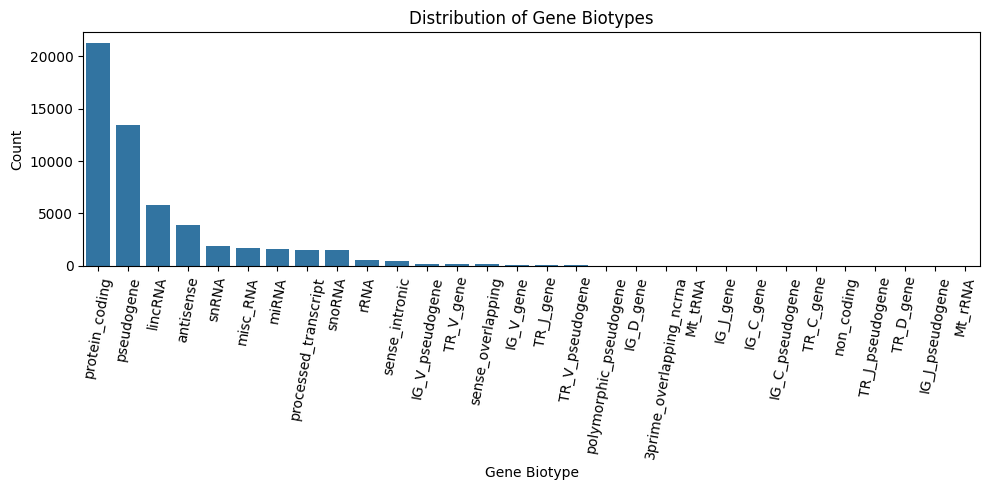

In [13]:
plt.figure(figsize=(10,5))
sns.countplot(data=df, x="gene_biotype", order=df["gene_biotype"].value_counts().index)
plt.xticks(rotation=80)
plt.title("Distribution of Gene Biotypes")
plt.xlabel("Gene Biotype")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

سؤال 12: چند ژن از نوع protein_coding هستند؟

هدف: بررسی سهم ژن‌های کدکننده پروتئین در دیتاست و ارزیابی اینکه چه بخشی از ژن‌های موجود مستقیماً می‌توانند بر تولید پروتئین‌ها و فرآیندهای سلولی مرتبط با پیری تأثیر بگذارند

<br>
<br>
<br>

همه ژن‌ها یک کار را انجام نمی‌دهند. به طور کلی ژن‌ها به دو گروه اصلی تقسیم می‌شوند:

Protein-coding genes (ژن‌های کدکننده پروتئین): این ژن‌ها اطلاعات لازم برای ساخت پروتئین را در خود دارند

Non-coding genes (ژن‌های غیرکدکننده): این ژن‌ها معمولاً پروتئین تولید نمی‌کنند و بیشتر نقش تنظیمی دارند

<br>
<br>
<br>
هدف پروژه این است که ژن‌هایی را پیدا کنی که با پیری سلولی ارتباط دارند

بسیاری از تغییرات مرتبط با پیری از طریق پروتئین‌ها اتفاق می‌افتند

In [14]:
print((df["gene_biotype"] == "protein_coding").sum())

21226


سؤال 13: چند ژن از نوع lncRNA یا سایر RNAهای غیرکدکننده هستند؟

هدف: بررسی حضور ژن‌های تنظیم‌کننده

In [15]:
controller_counts = df["gene_biotype"].isin([
    "lncRNA",
    "antisense",
    "processed_transcript",
    "sense_intronic",
    "sense_overlapping"
]).sum()

print(controller_counts)

6044


سؤال 14: چه تعداد نام ژن یکتا (external_gene_id) در دیتاست وجود دارد؟

هدف: بررسی تعداد ژن‌های منحصربه‌فرد

In [16]:
print(df["external_gene_id"].nunique())

47965


سؤال 15: آیا ژن‌هایی با نام تکراری (external_gene_id) وجود دارند؟

هدف: شناسایی ژن‌هایی که بیش از یک بار در دیتاست ثبت شده‌اند.

In [17]:
duplicate_genes = df["external_gene_id"].value_counts()
duplicate_genes = duplicate_genes[duplicate_genes > 1]
print(len(duplicate_genes))
duplicate_genes.head(20)


830


external_gene_id
U6             1278
Y_RNA           813
Metazoa_SRP     510
snoU13          465
7SK             288
U1              121
U7              112
U4               82
U3               82
U2               68
SNORD112         51
U6atac           38
SNORA70          31
SNORA31          27
U8               26
SNORA40          22
SNORA25          20
HLA-P            16
U4atac           16
SNORA63          13
Name: count, dtype: int64

سؤال 16: طول متن موجود در ستون description چگونه توزیع شده است؟

هدف: بررسی کیفیت و میزان اطلاعات توصیفی ژن‌ها.

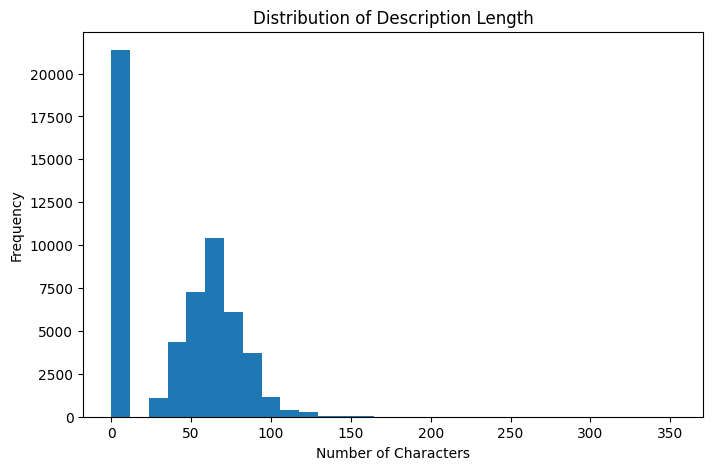

In [18]:
plt.figure(figsize=(8,5))
plt.hist(df["description"].fillna("").str.len(), bins=30)
plt.title("Distribution of Description Length")
plt.xlabel("Number of Characters")
plt.ylabel("Frequency")
plt.show()

سؤال 17: کدام ژن‌ها فاقد توضیح (description) هستند؟

هدف: شناسایی ژن‌هایی که اطلاعات عملکردی آن‌ها ناقص است

In [19]:
missing_description = df[df["description"].isna()]

print(len(missing_description))
missing_description[["ensembl_gene_id", "external_gene_id"]].head(20)

21372


,ensembl_gene_id,external_gene_id
1614,ENSG00000083622,AC000111.6
1855,ENSG00000089336,NaN
2015,ENSG00000093100,XXbac-B461K10.4
2131,ENSG00000099749,NaN
2153,ENSG00000099882,NaN
2213,ENSG00000100101,RP1-37E16.12
2510,ENSG00000101278,RPS10L
2613,ENSG00000101898,RP3-324O17.4
2806,ENSG00000103200,RP11-723C11.2
2882,ENSG00000103832,RP5-1086D14.1


بخش سوم: تحلیل ویژگی‌های عددی

سؤال 18: آمار توصیفی تمام ویژگی‌های عددی را استخراج کنید.

هدف: شناخت کلی توزیع مقادیر بیان ژن‌ها

In [20]:
numeric_cols = df.select_dtypes(include="number").columns
df[numeric_cols].describe()

,BJ_Y1,BJ_Y2,BJ_Y3,BJ_OLD_1,BJ_OLD_2,BJ_OLD_3,IMR90_Y1,IMR90_Y2,IMR90_Y3,IMR90_O1,...,HFF_PD16_3,HFF_PD74_1,HFF_PD74_2,HFF_PD74_3,MRC_5_PD32_1,MRC_5_PD32_2,MRC_5_PD32_3,MRC_5_PD72_1,MRC_5_PD72_2,MRC_5_PD72_3
count,56299.000000,56299.000000,56299.000000,56299.000000,56299.000000,56299.000000,56299.000000,56299.000000,56299.000000,56299.000000,...,56299.000000,56299.000000,56299.000000,56299.000000,56299.000000,56299.000000,56299.000000,56299.000000,56299.000000,56299.000000
mean,480.175740,672.518624,740.314801,456.320130,727.704489,545.922841,493.378586,678.878026,386.447610,579.773868,...,531.694435,526.727207,510.793726,562.113661,558.477469,601.271266,607.980852,606.566369,566.814650,554.918116
std,4318.201929,6073.885460,6575.700072,4171.219074,6628.915118,4959.533461,4455.627624,6324.144063,3470.998395,5208.426095,...,3869.537016,4773.651860,4887.267678,5390.779538,4219.179352,4638.055903,4547.063221,4729.436147,4640.071392,4374.000209
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,34.000000,46.000000,51.000000,34.000000,53.000000,40.000000,31.000000,44.000000,25.000000,36.000000,...,37.000000,39.000000,38.000000,41.000000,37.000000,39.000000,39.000000,35.000000,33.000000,33.000000
max,439272.000000,620606.000000,658800.000000,385125.000000,602586.000000,450389.000000,449614.000000,667913.000000,363618.000000,566057.000000,...,310230.000000,476192.000000,489748.000000,540430.000000,286842.000000,315741.000000,339995.000000,450448.000000,473487.000000,422152.000000


سؤال 19: میانگین هر ستون عددی را محاسبه کنید.

هدف: مقایسه میانگین بیان ژن‌ها در نمونه‌های مختلف.

In [21]:
df[numeric_cols].mean()

BJ_Y1           480.175740
BJ_Y2           672.518624
BJ_Y3           740.314801
BJ_OLD_1        456.320130
BJ_OLD_2        727.704489
BJ_OLD_3        545.922841
IMR90_Y1        493.378586
IMR90_Y2        678.878026
IMR90_Y3        386.447610
IMR90_O1        579.773868
IMR90_O2        429.768291
IMR90_O3        657.802661
WI_38_Y1        660.916997
WI_38_Y2        524.483081
WI_38_Y3        438.930336
WI_38_O1        586.507203
WI_38_O2        579.349385
WI_38_O3        501.911952
HFF_PD16_1      713.331285
HFF_PD16_2      552.123501
HFF_PD16_3      531.694435
HFF_PD74_1      526.727207
HFF_PD74_2      510.793726
HFF_PD74_3      562.113661
MRC_5_PD32_1    558.477469
MRC_5_PD32_2    601.271266
MRC_5_PD32_3    607.980852
MRC_5_PD72_1    606.566369
MRC_5_PD72_2    566.814650
MRC_5_PD72_3    554.918116
dtype: float64

سؤال 20: میانه هر ستون عددی را محاسبه کنید.

هدف: بررسی مقدار مرکزی داده‌ها.

In [22]:
df[numeric_cols].median()

BJ_Y1           0.0
BJ_Y2           0.0
BJ_Y3           0.0
BJ_OLD_1        0.0
BJ_OLD_2        0.0
BJ_OLD_3        0.0
IMR90_Y1        0.0
IMR90_Y2        0.0
IMR90_Y3        0.0
IMR90_O1        0.0
IMR90_O2        0.0
IMR90_O3        0.0
WI_38_Y1        0.0
WI_38_Y2        0.0
WI_38_Y3        0.0
WI_38_O1        0.0
WI_38_O2        0.0
WI_38_O3        0.0
HFF_PD16_1      1.0
HFF_PD16_2      0.0
HFF_PD16_3      0.0
HFF_PD74_1      0.0
HFF_PD74_2      0.0
HFF_PD74_3      0.0
MRC_5_PD32_1    0.0
MRC_5_PD32_2    0.0
MRC_5_PD32_3    0.0
MRC_5_PD72_1    0.0
MRC_5_PD72_2    0.0
MRC_5_PD72_3    0.0
dtype: float64

سؤال 21: مد (Mode) هر ستون عددی را محاسبه کنید.

هدف: بررسی پرتکرارترین مقدار در هر نمونه.

In [23]:
df[numeric_cols].mode().iloc[0]

BJ_Y1           0
BJ_Y2           0
BJ_Y3           0
BJ_OLD_1        0
BJ_OLD_2        0
BJ_OLD_3        0
IMR90_Y1        0
IMR90_Y2        0
IMR90_Y3        0
IMR90_O1        0
IMR90_O2        0
IMR90_O3        0
WI_38_Y1        0
WI_38_Y2        0
WI_38_Y3        0
WI_38_O1        0
WI_38_O2        0
WI_38_O3        0
HFF_PD16_1      0
HFF_PD16_2      0
HFF_PD16_3      0
HFF_PD74_1      0
HFF_PD74_2      0
HFF_PD74_3      0
MRC_5_PD32_1    0
MRC_5_PD32_2    0
MRC_5_PD32_3    0
MRC_5_PD72_1    0
MRC_5_PD72_2    0
MRC_5_PD72_3    0
Name: 0, dtype: int64

سؤال 22: واریانس هر ستون عددی را محاسبه کنید.

هدف: بررسی میزان پراکندگی بیان ژن‌ها.

In [24]:
df[numeric_cols].var()

BJ_Y1           1.864687e+07
BJ_Y2           3.689208e+07
BJ_Y3           4.323983e+07
BJ_OLD_1        1.739907e+07
BJ_OLD_2        4.394252e+07
BJ_OLD_3        2.459697e+07
IMR90_Y1        1.985262e+07
IMR90_Y2        3.999480e+07
IMR90_Y3        1.204783e+07
IMR90_O1        2.712770e+07
IMR90_O2        1.521897e+07
IMR90_O3        4.021424e+07
WI_38_Y1        2.864760e+07
WI_38_Y2        1.837551e+07
WI_38_Y3        1.285479e+07
WI_38_O1        2.762066e+07
WI_38_O2        2.430147e+07
WI_38_O3        1.496155e+07
HFF_PD16_1      2.712993e+07
HFF_PD16_2      1.600500e+07
HFF_PD16_3      1.497332e+07
HFF_PD74_1      2.278775e+07
HFF_PD74_2      2.388539e+07
HFF_PD74_3      2.906050e+07
MRC_5_PD32_1    1.780147e+07
MRC_5_PD32_2    2.151156e+07
MRC_5_PD32_3    2.067578e+07
MRC_5_PD72_1    2.236757e+07
MRC_5_PD72_2    2.153026e+07
MRC_5_PD72_3    1.913188e+07
dtype: float64

سؤال 23: انحراف معیار هر ستون عددی را محاسبه کنید.

هدف: مقایسه میزان تغییرپذیری بین نمونه‌ها.

In [25]:
df[numeric_cols].std()

BJ_Y1           4318.201929
BJ_Y2           6073.885460
BJ_Y3           6575.700072
BJ_OLD_1        4171.219074
BJ_OLD_2        6628.915118
BJ_OLD_3        4959.533461
IMR90_Y1        4455.627624
IMR90_Y2        6324.144063
IMR90_Y3        3470.998395
IMR90_O1        5208.426095
IMR90_O2        3901.149880
IMR90_O3        6341.470128
WI_38_Y1        5352.345444
WI_38_Y2        4286.665978
WI_38_Y3        3585.357655
WI_38_O1        5255.535699
WI_38_O2        4929.652418
WI_38_O3        3868.016420
HFF_PD16_1      5208.639690
HFF_PD16_2      4000.625244
HFF_PD16_3      3869.537016
HFF_PD74_1      4773.651860
HFF_PD74_2      4887.267678
HFF_PD74_3      5390.779538
MRC_5_PD32_1    4219.179352
MRC_5_PD32_2    4638.055903
MRC_5_PD32_3    4547.063221
MRC_5_PD72_1    4729.436147
MRC_5_PD72_2    4640.071392
MRC_5_PD72_3    4374.000209
dtype: float64

سؤال 24: کمترین مقدار هر ستون عددی را پیدا کنید.

هدف: بررسی حداقل میزان بیان ژن‌ها.

In [26]:
df[numeric_cols].min()

BJ_Y1           0
BJ_Y2           0
BJ_Y3           0
BJ_OLD_1        0
BJ_OLD_2        0
BJ_OLD_3        0
IMR90_Y1        0
IMR90_Y2        0
IMR90_Y3        0
IMR90_O1        0
IMR90_O2        0
IMR90_O3        0
WI_38_Y1        0
WI_38_Y2        0
WI_38_Y3        0
WI_38_O1        0
WI_38_O2        0
WI_38_O3        0
HFF_PD16_1      0
HFF_PD16_2      0
HFF_PD16_3      0
HFF_PD74_1      0
HFF_PD74_2      0
HFF_PD74_3      0
MRC_5_PD32_1    0
MRC_5_PD32_2    0
MRC_5_PD32_3    0
MRC_5_PD72_1    0
MRC_5_PD72_2    0
MRC_5_PD72_3    0
dtype: int64

سؤال 25: بیشترین مقدار هر ستون عددی را پیدا کنید.

هدف: بررسی حداکثر میزان بیان ژن‌ها.

In [27]:
df[numeric_cols].max()

BJ_Y1           439272
BJ_Y2           620606
BJ_Y3           658800
BJ_OLD_1        385125
BJ_OLD_2        602586
BJ_OLD_3        450389
IMR90_Y1        449614
IMR90_Y2        667913
IMR90_Y3        363618
IMR90_O1        566057
IMR90_O2        388220
IMR90_O3        637416
WI_38_Y1        645491
WI_38_Y2        534996
WI_38_Y3        452079
WI_38_O1        635599
WI_38_O2        585189
WI_38_O3        395475
HFF_PD16_1      395891
HFF_PD16_2      338724
HFF_PD16_3      310230
HFF_PD74_1      476192
HFF_PD74_2      489748
HFF_PD74_3      540430
MRC_5_PD32_1    286842
MRC_5_PD32_2    315741
MRC_5_PD32_3    339995
MRC_5_PD72_1    450448
MRC_5_PD72_2    473487
MRC_5_PD72_3    422152
dtype: int64

سؤال 26: دامنه (Range) هر ستون عددی را محاسبه کنید.

هدف: بررسی اختلاف بین بیشترین و کمترین مقدار.

In [28]:
df[numeric_cols].max() - df[numeric_cols].min()

BJ_Y1           439272
BJ_Y2           620606
BJ_Y3           658800
BJ_OLD_1        385125
BJ_OLD_2        602586
BJ_OLD_3        450389
IMR90_Y1        449614
IMR90_Y2        667913
IMR90_Y3        363618
IMR90_O1        566057
IMR90_O2        388220
IMR90_O3        637416
WI_38_Y1        645491
WI_38_Y2        534996
WI_38_Y3        452079
WI_38_O1        635599
WI_38_O2        585189
WI_38_O3        395475
HFF_PD16_1      395891
HFF_PD16_2      338724
HFF_PD16_3      310230
HFF_PD74_1      476192
HFF_PD74_2      489748
HFF_PD74_3      540430
MRC_5_PD32_1    286842
MRC_5_PD32_2    315741
MRC_5_PD32_3    339995
MRC_5_PD72_1    450448
MRC_5_PD72_2    473487
MRC_5_PD72_3    422152
dtype: int64

سؤال 27: چارک‌های اول، دوم و سوم هر ستون عددی را محاسبه کنید.

هدف: شناخت بهتر توزیع داده‌ها.

In [29]:
df[numeric_cols].quantile([0.25, 0.50, 0.75])

,BJ_Y1,BJ_Y2,BJ_Y3,BJ_OLD_1,BJ_OLD_2,BJ_OLD_3,IMR90_Y1,IMR90_Y2,IMR90_Y3,IMR90_O1,...,HFF_PD16_3,HFF_PD74_1,HFF_PD74_2,HFF_PD74_3,MRC_5_PD32_1,MRC_5_PD32_2,MRC_5_PD32_3,MRC_5_PD72_1,MRC_5_PD72_2,MRC_5_PD72_3
0.25,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
0.50,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
0.75,34.0,46.0,51.0,34.0,53.0,40.0,31.0,44.0,25.0,36.0,...,37.0,39.0,38.0,41.0,37.0,39.0,39.0,35.0,33.0,33.0


سؤال 28: هیستوگرام تمام ویژگی‌های عددی را رسم کنید.

هدف: بررسی شکل توزیع مقادیر بیان ژن‌ها.

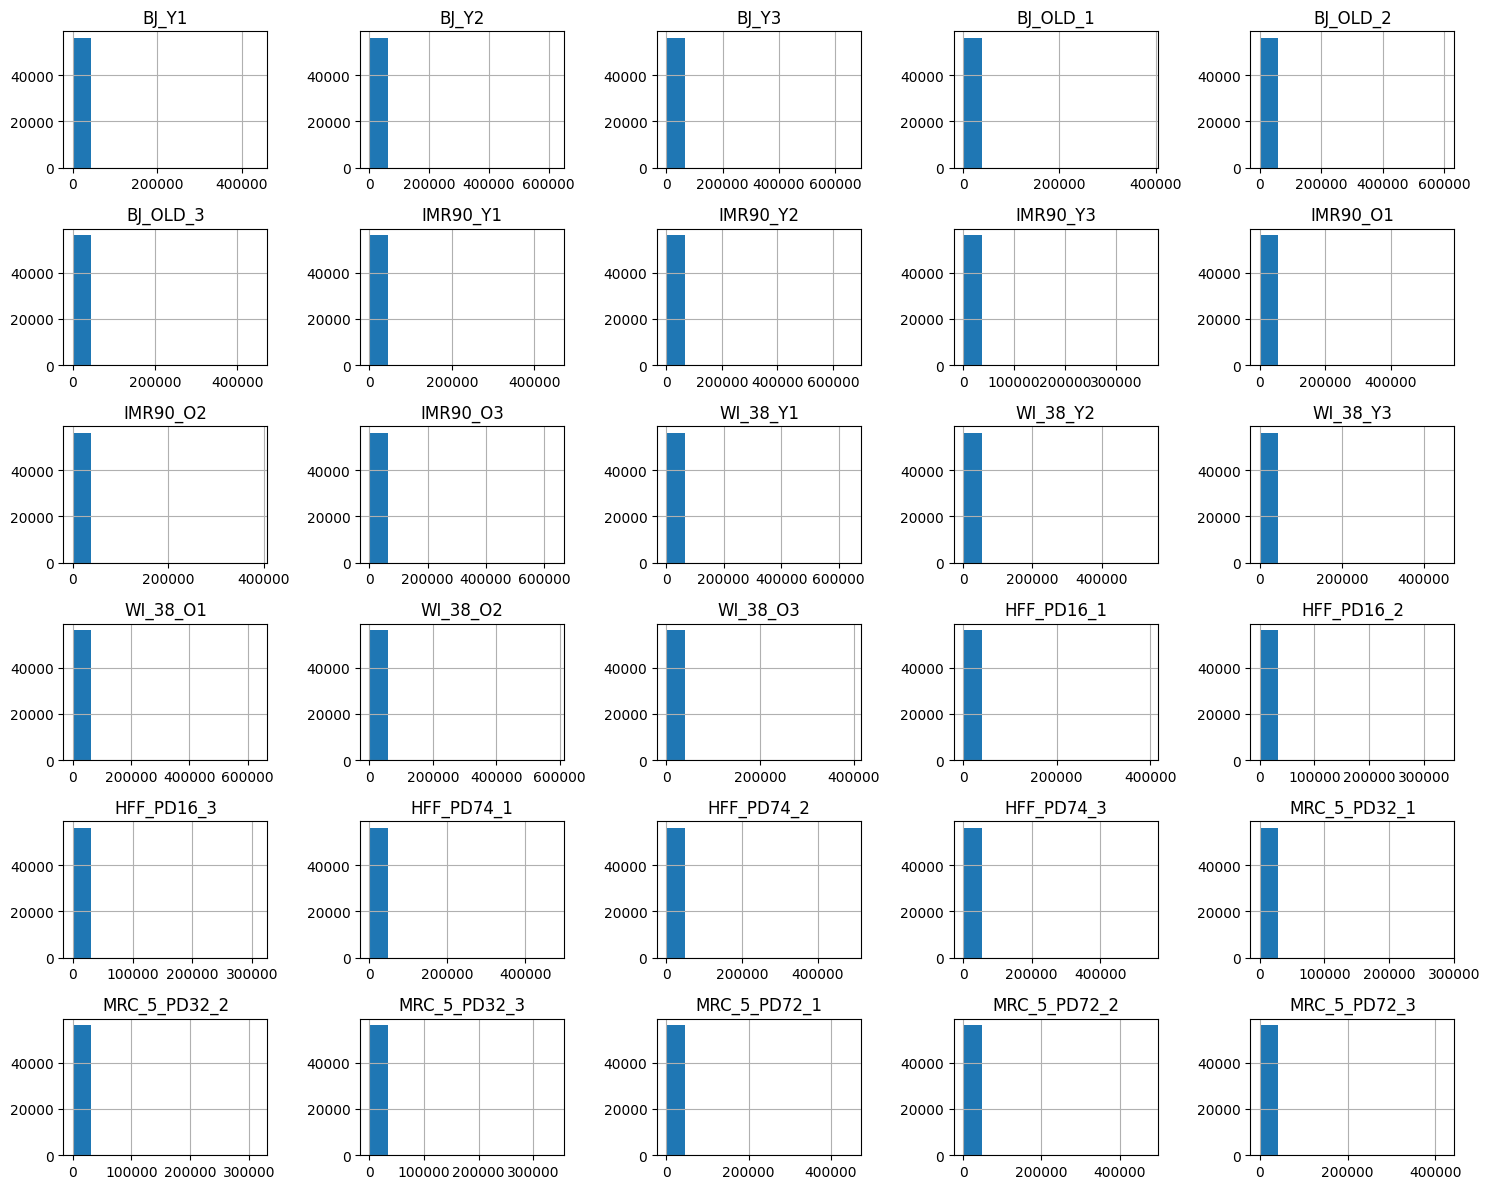

In [30]:
df[numeric_cols].hist(figsize=(15,12))
plt.tight_layout()
plt.show()

سؤال 29: Boxplot تمام ویژگی‌های عددی را رسم کنید.

هدف: بررسی پراکندگی و وجود مقادیر دورافتاده.

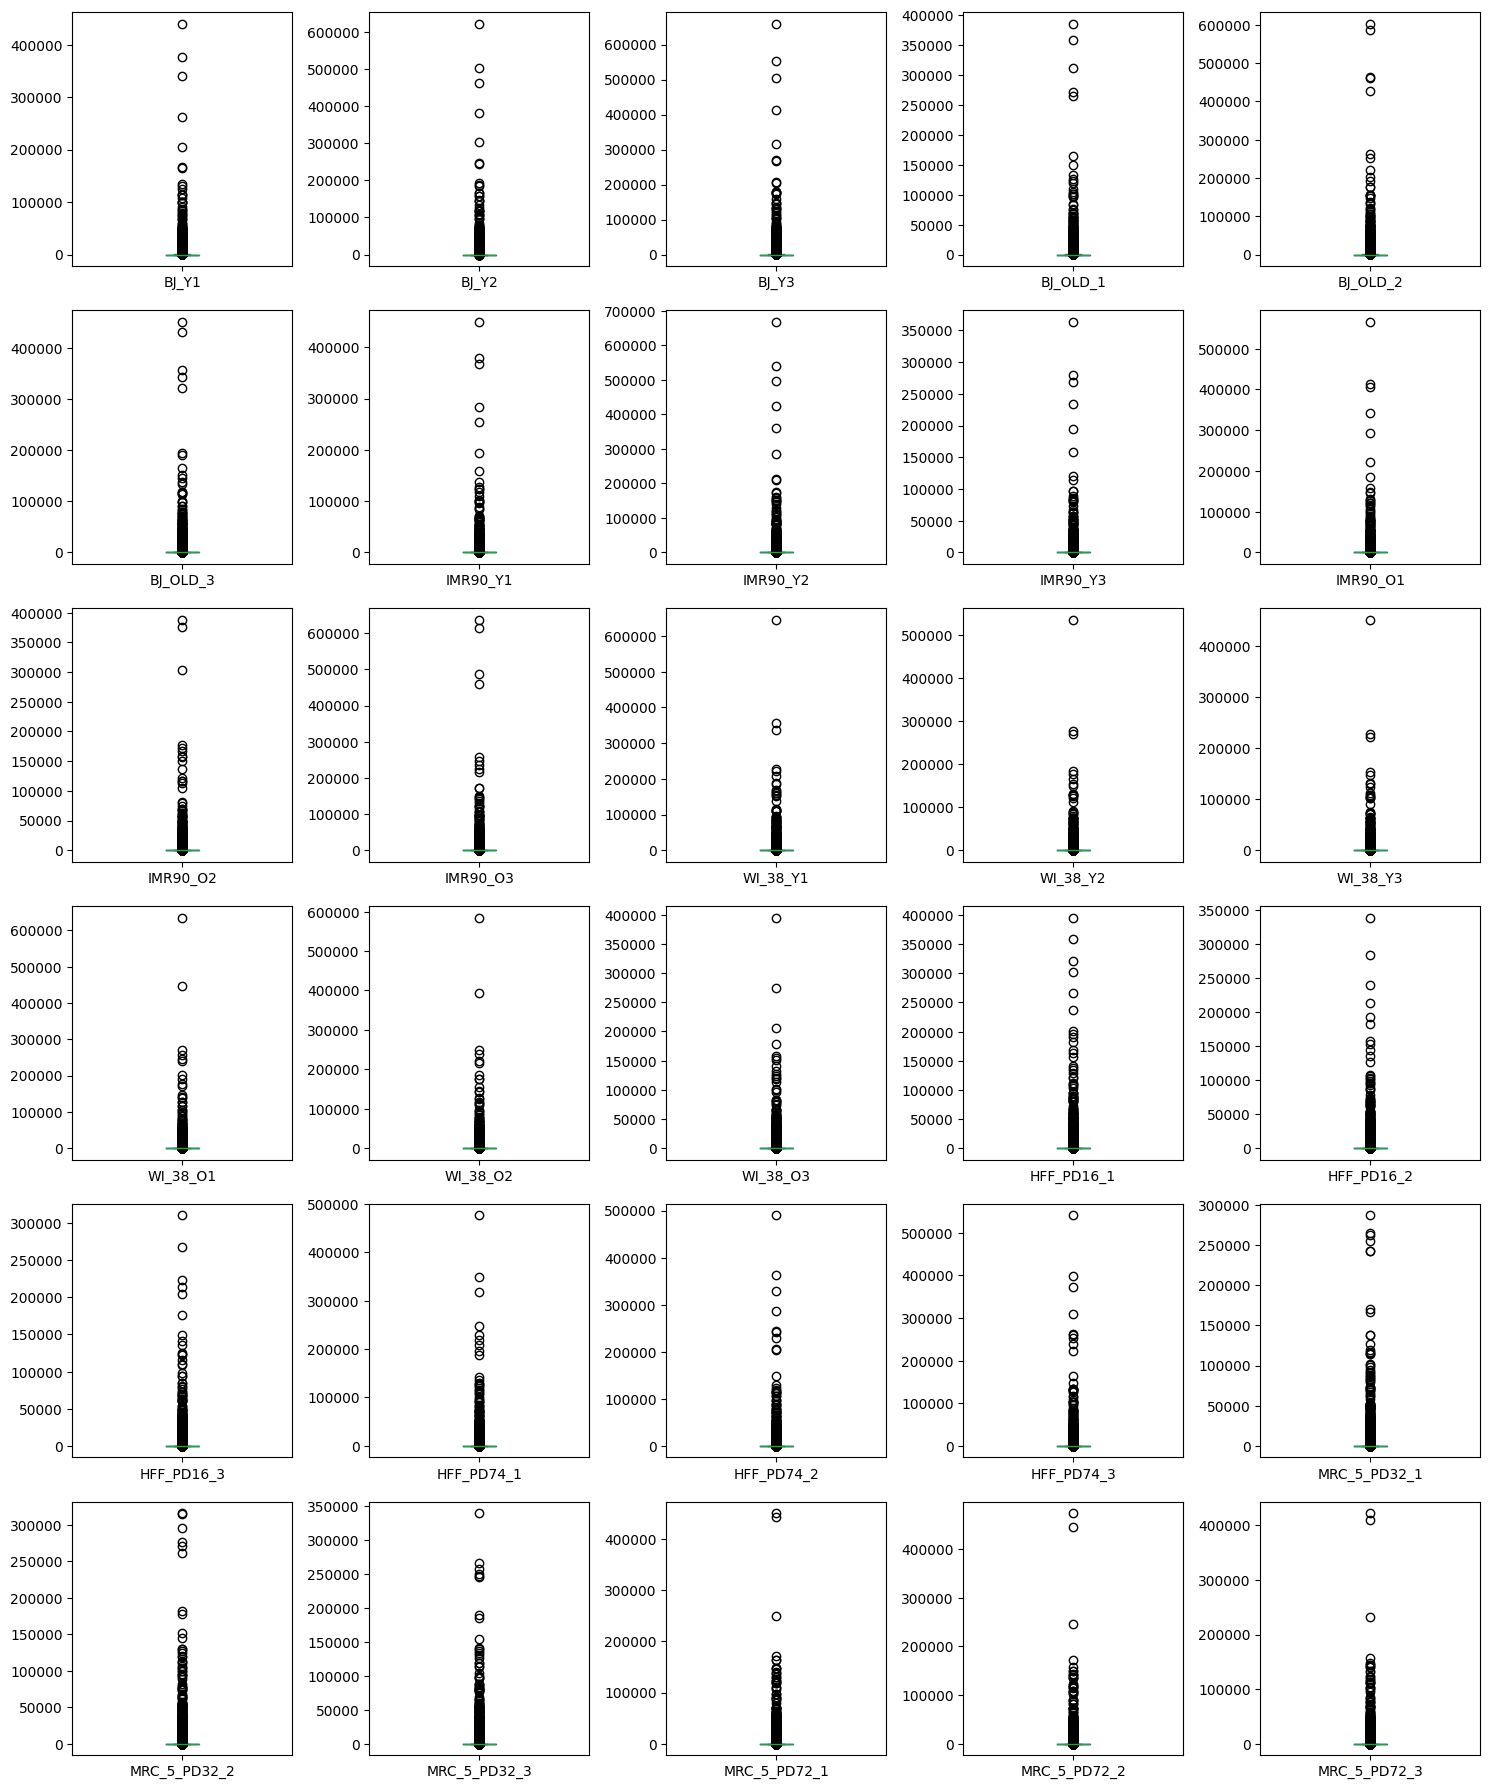

In [31]:
df[numeric_cols].plot(
    kind="box",
    subplots=True,
    layout=(6, 5),   # 6 سطر و 5 ستون (در مجموع 30 نمودار)
    figsize=(15, 18),
    sharex=False,
    sharey=False
)

plt.tight_layout()
plt.show()

سؤال 30: توزیع و چگالی مقادیر بیان ژن‌ها را در هر نمونه بررسی کنید.

هدف: بررسی چگالی توزیع مقادیر بیان ژن‌ها و مقایسه شکل توزیع بین نمونه‌های مختلف.

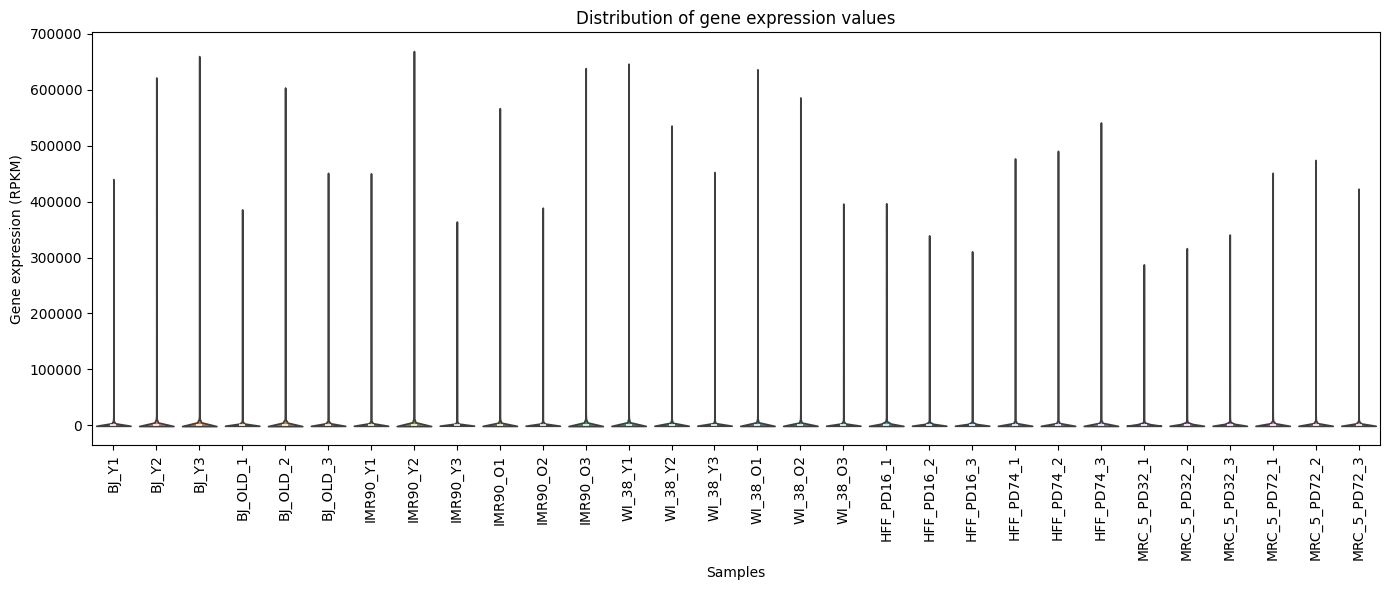

In [32]:
plt.figure(figsize=(14,6))
sns.violinplot(data=df[numeric_cols])

plt.xticks(rotation=90)
plt.title("Distribution of gene expression values")
plt.xlabel("Samples")
plt.ylabel("Gene expression (RPKM)")
plt.tight_layout()
plt.show()

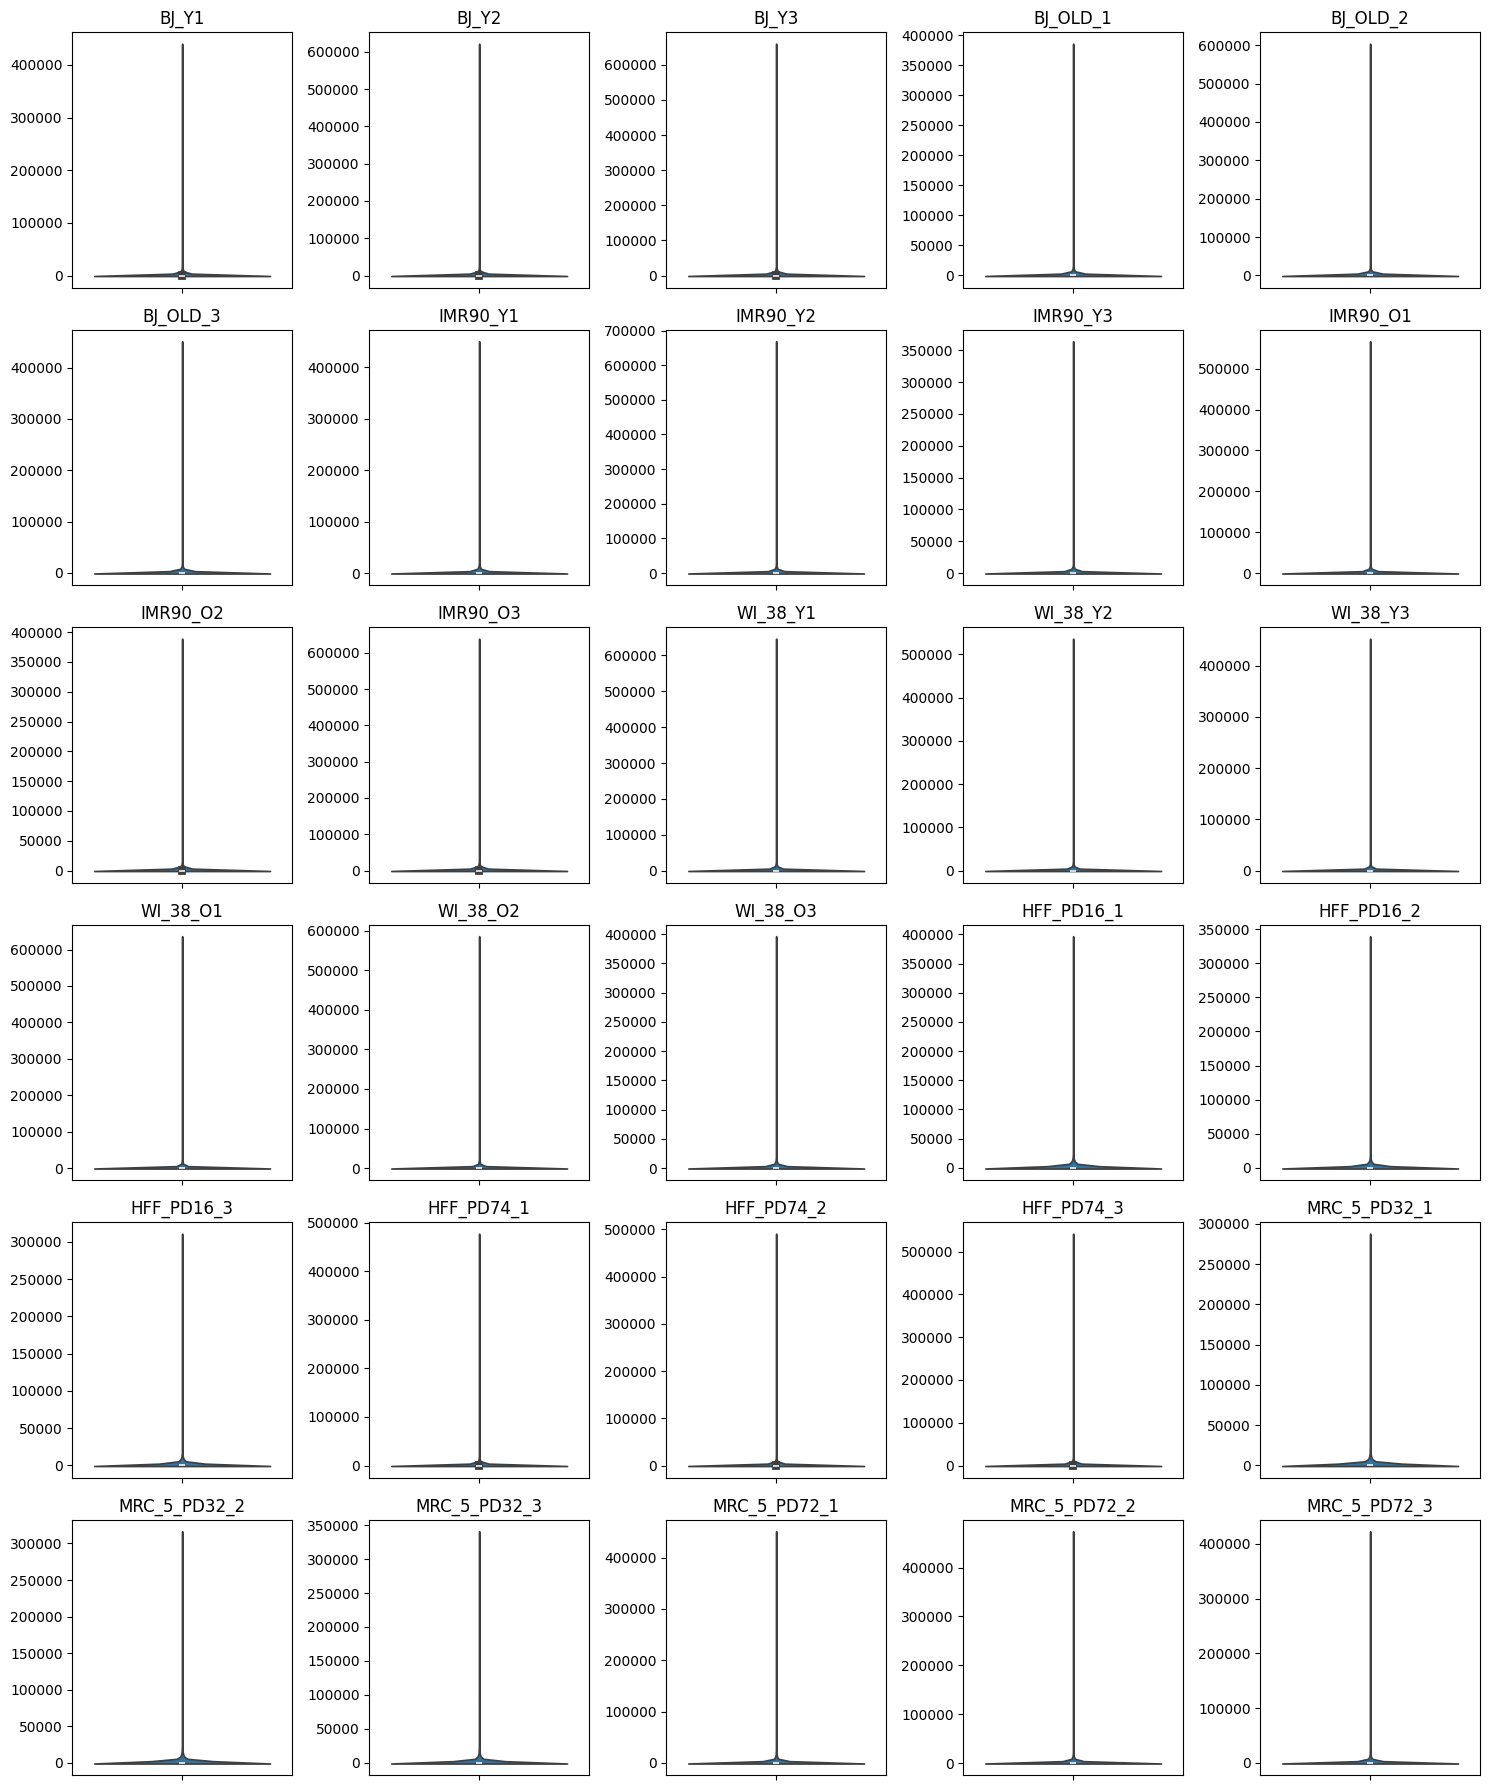

In [33]:
fig, axes = plt.subplots(6, 5, figsize=(15, 18))
axes = axes.flatten()

for i, col in enumerate(numeric_cols):
    sns.violinplot(y=df[col], ax=axes[i])
    axes[i].set_title(col)
    axes[i].set_xlabel("")
    axes[i].set_ylabel("")

plt.tight_layout()
plt.show()

سؤال 31: آیا مقادیر صفر در ستون‌های عددی وجود دارد؟

هدف: بررسی ژن‌هایی که در برخی نمونه‌ها بیان نشده‌اند

In [34]:
(df[numeric_cols] == 0).sum()

BJ_Y1           29399
BJ_Y2           28688
BJ_Y3           28395
BJ_OLD_1        29663
BJ_OLD_2        28173
BJ_OLD_3        29000
IMR90_Y1        30008
IMR90_Y2        28975
IMR90_Y3        30707
IMR90_O1        29253
IMR90_O2        29478
IMR90_O3        28400
WI_38_Y1        28934
WI_38_Y2        29650
WI_38_Y3        30205
WI_38_O1        28284
WI_38_O2        28380
WI_38_O3        29052
HFF_PD16_1      27841
HFF_PD16_2      28875
HFF_PD16_3      29003
HFF_PD74_1      28683
HFF_PD74_2      28740
HFF_PD74_3      28358
MRC_5_PD32_1    29027
MRC_5_PD32_2    28568
MRC_5_PD32_3    28830
MRC_5_PD72_1    29400
MRC_5_PD72_2    29282
MRC_5_PD72_3    29407
dtype: int64

سؤال 32: چه تعداد مقدار صفر در کل بخش عددی دیتاست وجود دارد؟

هدف: ارزیابی کلی میزان بیان صفر در داده‌ها.

In [35]:
(df[numeric_cols] == 0).sum().sum()

np.int64(870658)

بخش چهارم: تحلیل روابط بین ویژگی‌ها و استخراج الگوهای مرتبط با پیری

    بخش A: روابط بین نمونه‌های سلولی

سؤال 33

ماتریس همبستگی بین تمام نمونه‌های سلولی را محاسبه کنید.

هدف: بررسی میزان شباهت نمونه‌ها

In [36]:
corr = df[numeric_cols].corr()
corr

,BJ_Y1,BJ_Y2,BJ_Y3,BJ_OLD_1,BJ_OLD_2,BJ_OLD_3,IMR90_Y1,IMR90_Y2,IMR90_Y3,IMR90_O1,...,HFF_PD16_3,HFF_PD74_1,HFF_PD74_2,HFF_PD74_3,MRC_5_PD32_1,MRC_5_PD32_2,MRC_5_PD32_3,MRC_5_PD72_1,MRC_5_PD72_2,MRC_5_PD72_3
BJ_Y1,1.000000,0.998645,0.999011,0.887140,0.899010,0.897309,0.889518,0.878763,0.879745,0.874932,...,0.947367,0.857685,0.882351,0.878715,0.871010,0.873382,0.859431,0.816219,0.828892,0.822737
BJ_Y2,0.998645,1.000000,0.999608,0.882845,0.893787,0.892428,0.882493,0.870847,0.872144,0.866937,...,0.947729,0.858793,0.881806,0.878732,0.871382,0.874049,0.860737,0.826233,0.837943,0.831588
BJ_Y3,0.999011,0.999608,1.000000,0.882097,0.893420,0.891944,0.881616,0.869963,0.871343,0.866446,...,0.948072,0.856916,0.880293,0.876965,0.869615,0.871839,0.858548,0.818836,0.830181,0.824252
BJ_OLD_1,0.887140,0.882845,0.882097,1.000000,0.998403,0.998814,0.883039,0.887915,0.891482,0.887279,...,0.885415,0.926229,0.929183,0.927806,0.868948,0.869607,0.867627,0.787011,0.799360,0.802720
BJ_OLD_2,0.899010,0.893787,0.893420,0.998403,1.000000,0.999823,0.895395,0.899674,0.902389,0.898468,...,0.892622,0.919646,0.925802,0.923857,0.874321,0.874766,0.870903,0.785158,0.798451,0.800868
BJ_OLD_3,0.897309,0.892428,0.891944,0.998814,0.999823,1.000000,0.893654,0.897716,0.900678,0.896762,...,0.891218,0.921386,0.926566,0.924789,0.874190,0.874779,0.871163,0.787305,0.800557,0.803124
IMR90_Y1,0.889518,0.882493,0.881616,0.883039,0.895395,0.893654,1.000000,0.998162,0.998134,0.998133,...,0.868749,0.762588,0.783382,0.777958,0.936753,0.940666,0.919820,0.802032,0.822905,0.819839
IMR90_Y2,0.878763,0.870847,0.869963,0.887915,0.899674,0.897716,0.998162,1.000000,0.999216,0.998607,...,0.860831,0.763134,0.784051,0.778741,0.933720,0.936537,0.917303,0.788769,0.810421,0.807369
IMR90_Y3,0.879745,0.872144,0.871343,0.891482,0.902389,0.900678,0.998134,0.999216,1.000000,0.999392,...,0.864867,0.768781,0.787355,0.782320,0.938398,0.941362,0.923991,0.796113,0.816836,0.815204
IMR90_O1,0.874932,0.866937,0.866446,0.887279,0.898468,0.896762,0.998133,0.998607,0.999392,1.000000,...,0.858355,0.762627,0.781150,0.775760,0.933056,0.936504,0.917679,0.787614,0.808670,0.807272


سؤال 34

Heatmap ماتریس همبستگی را رسم کنید.

هدف: مشاهده الگوهای شباهت بین نمونه‌ها

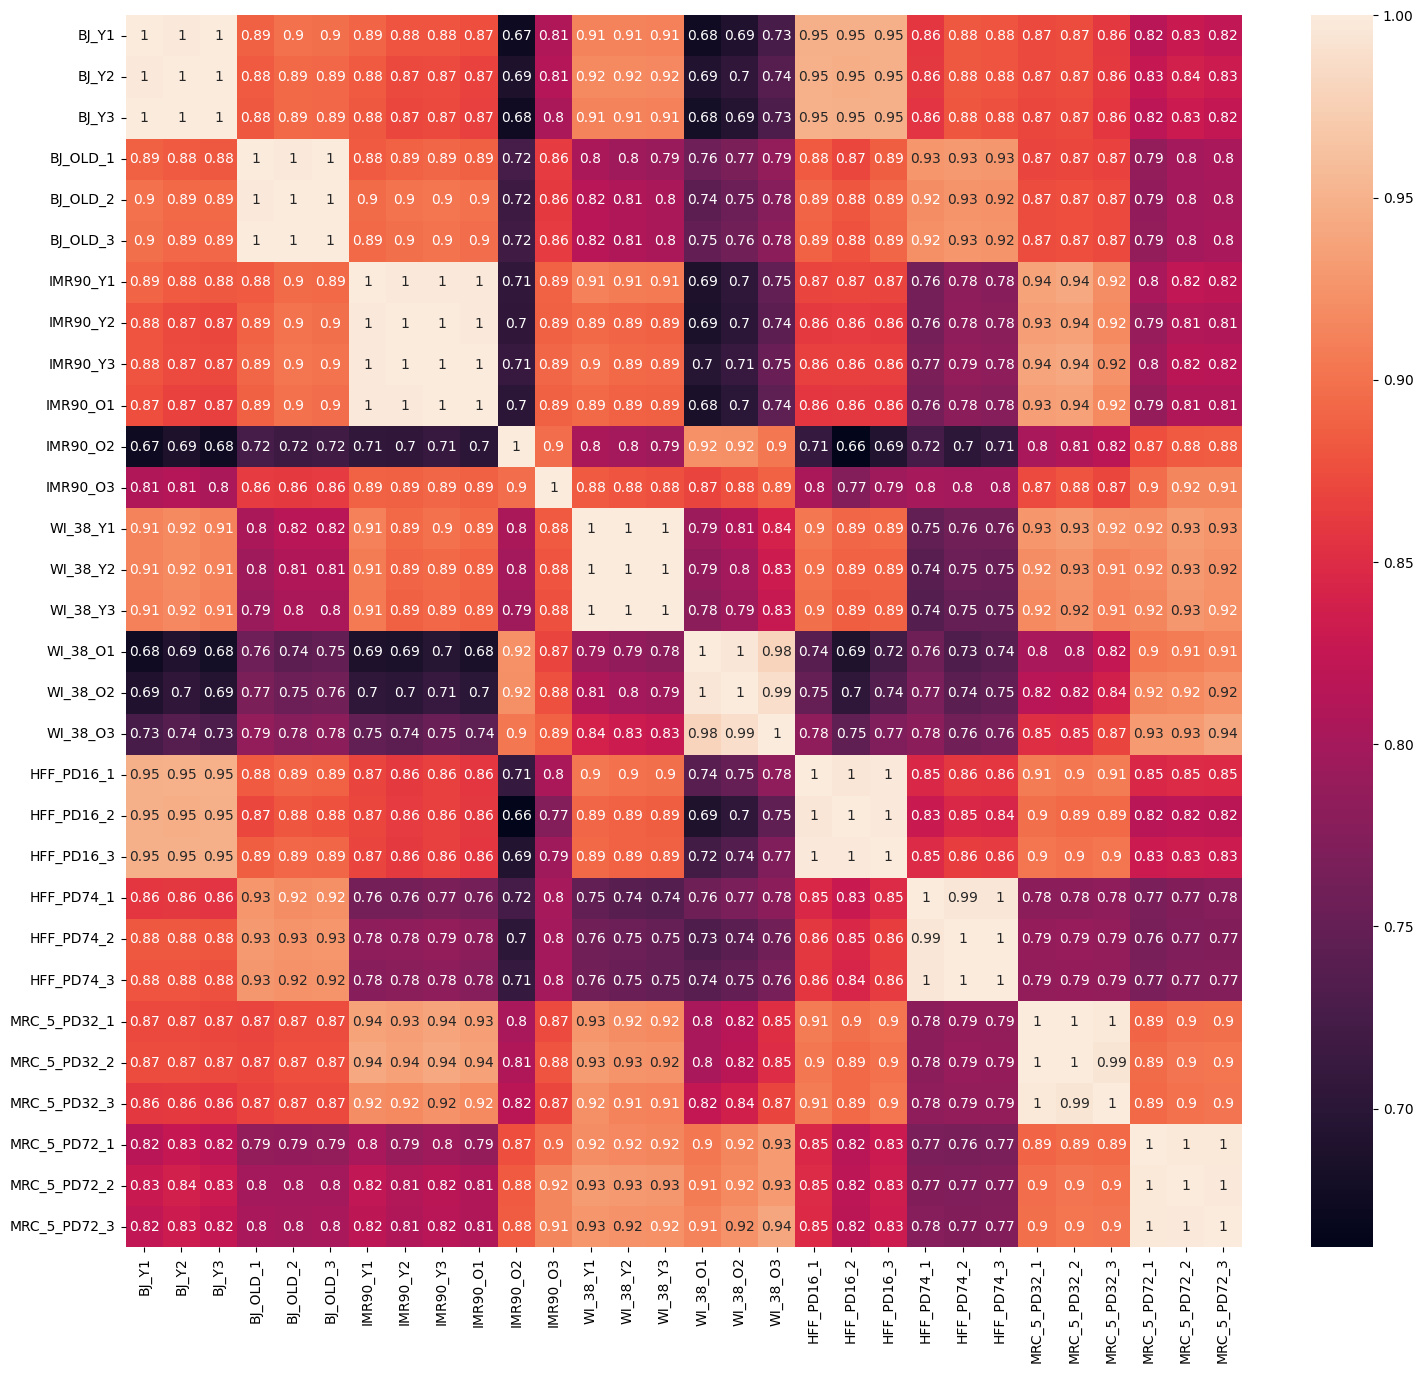

In [37]:
plt.figure(figsize=(18,16))
sns.heatmap(corr, annot=True)
# plt.grid()
plt.show()

سؤال 35

کدام دو نمونه بیشترین همبستگی را دارند؟

هدف: بررسی اینکه آیا تکرارهای زیستی (Replicates) به هم نزدیک هستند

In [38]:
corr.abs().unstack().sort_values(ascending=False).drop_duplicates().head(20)

WI_38_O2      WI_38_O2        1.000000
BJ_OLD_3      BJ_OLD_2        0.999823
HFF_PD74_2    HFF_PD74_3      0.999747
WI_38_Y3      WI_38_Y2        0.999658
BJ_Y3         BJ_Y2           0.999608
IMR90_Y3      IMR90_O1        0.999392
WI_38_Y1      WI_38_Y2        0.999257
WI_38_Y3      WI_38_Y1        0.999241
IMR90_Y2      IMR90_Y3        0.999216
BJ_Y1         BJ_Y3           0.999011
BJ_OLD_3      BJ_OLD_1        0.998814
MRC_5_PD32_2  MRC_5_PD32_1    0.998698
BJ_Y2         BJ_Y1           0.998645
IMR90_Y2      IMR90_O1        0.998607
MRC_5_PD72_3  MRC_5_PD72_2    0.998408
BJ_OLD_1      BJ_OLD_2        0.998403
HFF_PD16_3    HFF_PD16_1      0.998286
IMR90_Y1      IMR90_Y2        0.998162
IMR90_Y3      IMR90_Y1        0.998134
IMR90_Y1      IMR90_O1        0.998133
dtype: float64

سؤال 36

کدام دو نمونه کمترین همبستگی را دارند؟

هدف: شناسایی نمونه‌های متفاوت

In [39]:
corr.unstack().sort_values().head(20)

HFF_PD16_2  IMR90_O2      0.661882
IMR90_O2    HFF_PD16_2    0.661882
            BJ_Y1         0.673613
BJ_Y1       IMR90_O2      0.673613
BJ_Y3       IMR90_O2      0.675412
IMR90_O2    BJ_Y3         0.675412
WI_38_O1    BJ_Y1         0.675615
BJ_Y1       WI_38_O1      0.675615
WI_38_O1    BJ_Y3         0.679726
BJ_Y3       WI_38_O1      0.679726
IMR90_O1    WI_38_O1      0.684710
WI_38_O1    IMR90_O1      0.684710
            IMR90_Y2      0.686539
IMR90_Y2    WI_38_O1      0.686539
IMR90_O2    BJ_Y2         0.687729
BJ_Y2       IMR90_O2      0.687729
IMR90_Y1    WI_38_O1      0.687887
WI_38_O1    IMR90_Y1      0.687887
            HFF_PD16_2    0.689021
HFF_PD16_2  WI_38_O1      0.689021
dtype: float64

سؤال 37

میانگین همبستگی بین نمونه‌های Young را محاسبه کنید

In [40]:
young_cols = [
    "BJ_Y1", "BJ_Y2", "BJ_Y3",
    "IMR90_Y1", "IMR90_Y2", "IMR90_Y3",
    "WI_38_Y1", "WI_38_Y2", "WI_38_Y3",
    "HFF_PD16_1", "HFF_PD16_2", "HFF_PD16_3",
    "MRC_5_PD32_1", "MRC_5_PD32_2", "MRC_5_PD32_3"
]

old_cols = [
    "BJ_OLD_1", "BJ_OLD_2", "BJ_OLD_3",
    "IMR90_O1", "IMR90_O2", "IMR90_O3",
    "WI_38_O1", "WI_38_O2", "WI_38_O3",
    "HFF_PD74_1", "HFF_PD74_2", "HFF_PD74_3",
    "MRC_5_PD72_1", "MRC_5_PD72_2", "MRC_5_PD72_3"
]


corr_young = df[young_cols].corr()

mean_young = (corr_young.values.sum() - len(young_cols)) / (len(young_cols) * (len(young_cols) - 1))

print(mean_young)

0.9154123874507246


سؤال 38

میانگین همبستگی بین نمونه‌های Old را محاسبه کنید

In [41]:
corr_old = df[old_cols].corr()

mean_old = (corr_old.values.sum() - len(old_cols)) / (len(old_cols) * (len(old_cols) - 1))

print(mean_old)

0.8415170987695317


سؤال 39

میانگین همبستگی بین Young و Old را محاسبه کنید

In [42]:
corr_all = df[young_cols + old_cols].corr()

cross_corr = corr_all.loc[young_cols, old_cols]

mean_cross = cross_corr.values.mean()

print(mean_cross)

0.8247982126786992


    بخش B: تحلیل تفاوت بیان ژن‌ها

سؤال 40: میانگین بیان هر ژن در گروه Young را محاسبه کنید.

هدف: محاسبه میانگین بیان هر ژن در تمام نمونه‌های جوان

In [43]:
young_mean = df[young_cols].mean(axis=1)
young_mean

0         842.000000
1           0.000000
2        1178.466667
3         262.333333
4         362.066667
            ...     
56294       0.666667
56295       3.933333
56296      14.933333
56297       0.000000
56298       1.266667
Length: 56299, dtype: float64

سؤال 41: میانگین بیان هر ژن در گروه Old را محاسبه کنید.

هدف: محاسبه میانگین بیان هر ژن در تمام نمونه‌های پیر

In [44]:
old_mean = df[old_cols].mean(axis=1)
old_mean

0        1611.200000
1           0.066667
2        1153.066667
3         256.600000
4         153.933333
            ...     
56294       0.533333
56295       4.666667
56296      12.533333
56297       0.000000
56298       0.866667
Length: 56299, dtype: float64

سؤال 42: اختلاف بیان (Old − Young) را برای هر ژن محاسبه کنید.

هدف: شناسایی میزان تغییر بیان ژن‌ها در اثر پیری

In [45]:
difference = old_mean - young_mean
difference

0        769.200000
1          0.066667
2        -25.400000
3         -5.733333
4       -208.133333
            ...    
56294     -0.133333
56295      0.733333
56296     -2.400000
56297      0.000000
56298     -0.400000
Length: 56299, dtype: float64

سؤال 43: ژن‌ها را بر اساس اختلاف بیان (Old − Young) مرتب کنید.

هدف: شناسایی ژن‌هایی که بیشترین تغییر بیان را بین سلول‌های جوان و پیر دارند

In [46]:
comparison = pd.DataFrame({
    "Gene": df["external_gene_id"],
    "Gene_Type": df["gene_biotype"],
    "Young_Mean": young_mean,
    "Old_Mean": old_mean,
    "Difference": difference
})

comparison.sort_values("Difference", ascending=False)

,Gene,Gene_Type,Young_Mean,Old_Mean,Difference
18353,MT-CO1,protein_coding,263598.600000,410341.600000,146743.000000
18403,MT-ND4,protein_coding,159326.200000,276530.400000,117204.200000
4478,IGFBP5,protein_coding,232246.400000,296760.000000,64513.600000
18341,MT-ND5,protein_coding,52492.066667,112916.733333,60424.666667
7620,THBS1,protein_coding,179992.466667,234185.066667,54192.600000
...,...,...,...,...,...
15933,ACTG1,protein_coding,154735.066667,82105.000000,-72630.066667
1330,ACTB,protein_coding,192018.933333,112922.400000,-79096.533333
11125,COL6A3,protein_coding,184008.800000,98194.400000,-85814.400000
4469,FN1,protein_coding,407185.133333,311163.266667,-96021.866667


سؤال 44: 10 ژنی که بیشترین افزایش بیان را در سلول‌های پیر دارند شناسایی کنید.

هدف: یافتن ژن‌هایی که در سلول‌های پیر نسبت به سلول‌های جوان بیشترین افزایش بیان را داشته‌اند

In [47]:
comparison.nlargest(10, "Difference")

,Gene,Gene_Type,Young_Mean,Old_Mean,Difference
18353,MT-CO1,protein_coding,263598.600000,410341.600000,146743.000000
18403,MT-ND4,protein_coding,159326.200000,276530.400000,117204.200000
4478,IGFBP5,protein_coding,232246.400000,296760.000000,64513.600000
18341,MT-ND5,protein_coding,52492.066667,112916.733333,60424.666667
7620,THBS1,protein_coding,179992.466667,234185.066667,54192.600000
18311,MT-CYB,protein_coding,62883.200000,114698.733333,51815.533333
22546,J01415.4,Mt_rRNA,93371.133333,142959.466667,49588.333333
39280,hsa-mir-6723,pseudogene,87121.533333,135605.000000,48483.466667
3787,CCND1,protein_coding,36283.733333,77864.866667,41581.133333
18435,MT-CO3,protein_coding,123584.200000,164921.666667,41337.466667


سؤال 45: 10 ژنی که بیشترین کاهش بیان را در سلول‌های پیر دارند شناسایی کنید.

هدف: یافتن ژن‌هایی که در سلول‌های پیر نسبت به سلول‌های جوان بیشترین کاهش بیان را داشته‌اند

In [48]:
comparison.nsmallest(10, "Difference")

,Gene,Gene_Type,Young_Mean,Old_Mean,Difference
3631,COL1A1,protein_coding,353136.933333,217031.933333,-136105.000000
4469,FN1,protein_coding,407185.133333,311163.266667,-96021.866667
11125,COL6A3,protein_coding,184008.800000,98194.400000,-85814.400000
1330,ACTB,protein_coding,192018.933333,112922.400000,-79096.533333
15933,ACTG1,protein_coding,154735.066667,82105.000000,-72630.066667
17663,FLNA,protein_coding,146137.133333,89158.266667,-56978.866667
458,VIM,protein_coding,127399.066667,82316.333333,-45082.733333
3955,GAPDH,protein_coding,103137.000000,67016.733333,-36120.266667
11561,COL1A2,protein_coding,298191.266667,262929.066667,-35262.200000
12251,TPM4,protein_coding,71091.266667,40464.733333,-30626.533333


سؤال 46: نمودار میله‌ای 10 ژن با بیشترین افزایش بیان را رسم کنید

هدف: نمایش بصری مهم‌ترین ژن‌های افزایش‌یافته

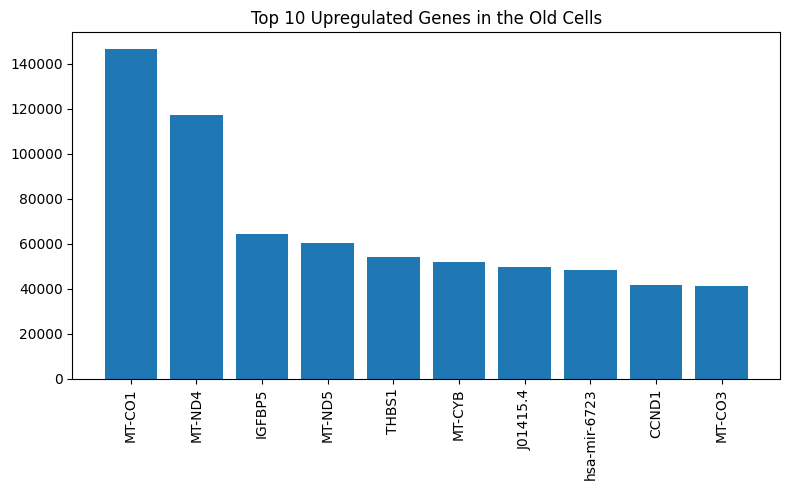

In [49]:
top_up = comparison.nlargest(10, "Difference")

plt.figure(figsize=(8,5))
plt.bar(top_up["Gene"], top_up["Difference"])
plt.xticks(rotation=90)
plt.title("Top 10 Upregulated Genes in the Old Cells")
plt.tight_layout()
plt.show()

سؤال 47: نمودار میله‌ای 10 ژن با بیشترین کاهش بیان را رسم کنید

هدف: نمایش بصری ژن‌های کاهش‌یافته

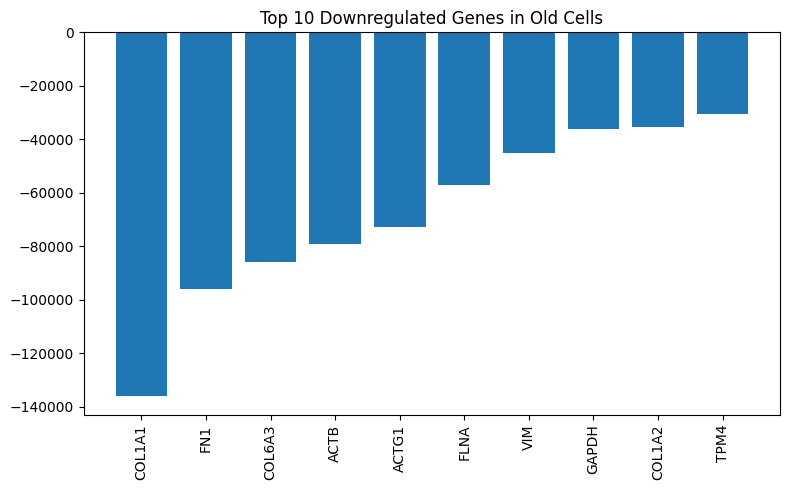

In [50]:
top_down = comparison.nsmallest(10, "Difference")

plt.figure(figsize=(8,5))
plt.bar(top_down["Gene"], top_down["Difference"])
plt.xticks(rotation=90)
plt.title("Top 10 Downregulated Genes in Old Cells")
plt.tight_layout()
plt.show()

سؤال 48: توزیع اختلاف بیان ژن‌ها را رسم کنید

هدف: بررسی اینکه بیشتر ژن‌ها افزایش بیان داشته‌اند یا کاهش

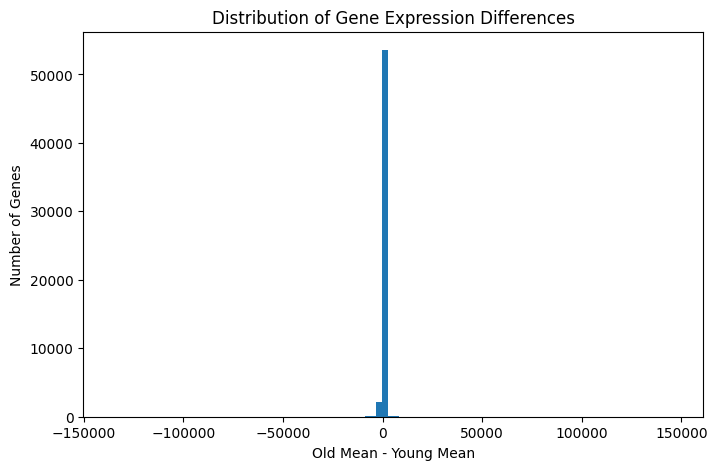

In [51]:
plt.figure(figsize=(8,5))
plt.hist(comparison["Difference"], bins=100)
plt.title("Distribution of Gene Expression Differences")
plt.xlabel("Old Mean - Young Mean")
plt.ylabel("Number of Genes")
plt.show()

    بخش C: ژن‌های مرتبط با پیری

سؤال 49: چه تعداد ژن در سلول‌های پیر بیان بیشتری نسبت به سلول‌های جوان دارند؟

هدف: شمارش ژن‌های فعال‌شده در پیری

In [52]:
(comparison["Difference"] > 0).sum()

np.int64(18559)

سؤال 50: چه تعداد ژن در سلول‌های پیر بیان کمتری نسبت به سلول‌های جوان دارند؟

هدف: شمارش ژن‌های کاهش‌یافته در پیری

In [53]:
(comparison["Difference"] < 0).sum()

np.int64(19565)

سؤال 51: چه تعداد ژن اختلاف بیان دقیقاً برابر صفر دارند؟

هدف: شناسایی ژن‌هایی که تغییری نداشته‌اند

In [54]:
(comparison["Difference"] == 0).sum()

np.int64(18175)

سؤال 52: ژن‌هایی را پیدا کنید که اختلاف بیان آن‌ها بیشتر از 100 باشد

هدف: استخراج ژن‌های با تغییر بیان بسیار زیاد

In [55]:
comparison[comparison["Difference"] > 100]

,Gene,Gene_Type,Young_Mean,Old_Mean,Difference
0,TSPAN6,protein_coding,842.000000,1611.200000,769.200000
6,CFH,protein_coding,1097.800000,2781.133333,1683.333333
8,GCLC,protein_coding,1149.600000,1407.400000,257.800000
11,NIPAL3,protein_coding,3543.400000,8472.666667,4929.266667
13,ENPP4,protein_coding,83.200000,851.866667,768.666667
...,...,...,...,...,...
55571,TMEM178B,protein_coding,34.066667,1649.400000,1615.333333
55635,RP11-13L2.4,sense_overlapping,5.600000,1209.733333,1204.133333
55881,RP11-709B3.2,lincRNA,97.000000,212.933333,115.933333
56053,RP11-353B9.1,sense_overlapping,85.866667,188.333333,102.466667


سؤال 53: ژن‌هایی را پیدا کنید که اختلاف بیان آن‌ها کمتر از -100 باشد

هدف: شناسایی ژن‌های با کاهش شدید بیان

In [56]:
comparison[comparison["Difference"] < -100]

,Gene,Gene_Type,Young_Mean,Old_Mean,Difference
4,C1orf112,protein_coding,362.066667,153.933333,-208.133333
7,FUCA2,protein_coding,3470.266667,3202.200000,-268.066667
9,NFYA,protein_coding,1235.066667,922.133333,-312.933333
12,LAS1L,protein_coding,1329.733333,1062.933333,-266.800000
14,SEMA3F,protein_coding,1598.533333,1315.333333,-283.200000
...,...,...,...,...,...
54716,RP11-304L19.5,lincRNA,300.866667,134.666667,-166.200000
54746,CTD-2033A16.2,pseudogene,950.466667,652.466667,-298.000000
55946,RP11-448G15.3,sense_overlapping,352.533333,162.000000,-190.533333
56015,RP11-1H8.3,pseudogene,285.400000,151.933333,-133.466667


سؤال 54: میانگین اختلاف بیان ژن‌های protein_coding را محاسبه کنید

هدف: بررسی رفتار ژن‌های کدکننده پروتئین

In [57]:
comparison[comparison["Gene_Type"] == "protein_coding"]["Difference"].mean()

np.float64(-50.175639938440284)

سؤال 55: میانگین اختلاف بیان ژن‌های lncRNA را محاسبه کنید

هدف: بررسی رفتار RNAهای بلند غیرکدکننده

In [58]:
comparison[comparison["Gene_Type"] == "lncRNA"]["Difference"].mean()

nan

سؤال 56: میانگین اختلاف بیان هر نوع ژن (gene_biotype) را محاسبه کنید

هدف: مقایسه رفتار انواع مختلف ژن‌ها

In [59]:
comparison.groupby("Gene_Type")["Difference"].mean().sort_values(ascending=False)

Gene_Type
Mt_rRNA                     30941.433333
Mt_tRNA                       181.700000
sense_overlapping              23.390698
polymorphic_pseudogene         11.349425
lincRNA                         6.267152
pseudogene                      1.538451
antisense                       0.782647
miRNA                           0.591824
IG_C_gene                       0.347619
rRNA                            0.246927
non_coding                      0.146667
TR_V_pseudogene                 0.065000
TR_J_pseudogene                 0.016667
IG_J_pseudogene                 0.000000
IG_D_gene                       0.000000
IG_J_gene                       0.000000
IG_V_pseudogene                -0.001766
IG_V_gene                      -0.005291
TR_V_gene                      -0.014222
misc_RNA                       -0.014305
TR_D_gene                      -0.022222
snRNA                          -0.025341
IG_C_pseudogene                -0.114286
TR_J_gene                      -0.327642
snoRNA

بخش پنجم: جمع‌بندی و استخراج نتایج نهایی


سؤال 57: آیا تعداد ژن‌هایی که در سلول‌های پیر افزایش بیان دارند بیشتر است یا ژن‌هایی که کاهش بیان دارند؟

هدف: تعیین جهت کلی تغییرات ژنتیکی در فرآیند پیری

In [60]:
print((comparison["Difference"] > 0).sum())
print((comparison["Difference"] < 0).sum())

18559
19565


سؤال 58: چه درصدی از ژن‌ها در سلول‌های پیر افزایش بیان دارند؟

هدف: اندازه‌گیری سهم ژن‌های فعال‌شده در پیری

In [61]:
print((comparison["Difference"] > 0).mean() * 100)

32.96506154638626


سؤال 59: چه درصدی از ژن‌ها در سلول‌های پیر کاهش بیان دارند؟

هدف: اندازه‌گیری سهم ژن‌های خاموش‌شده در پیری

In [62]:
print((comparison["Difference"] < 0).mean() * 100)

34.751949412955824


سؤال 60: ژن‌هایی که بیشترین تغییر بیان را دارند، متعلق به چه نوع ژنی هستند؟

هدف: بررسی اینکه کدام gene_biotype در ژن‌های با تغییر شدید غالب است

In [63]:
top20 = comparison.reindex(comparison["Difference"].abs().sort_values(ascending=False).index).head(20)

top20["Gene_Type"].value_counts()

Gene_Type
protein_coding    18
Mt_rRNA            1
pseudogene         1
Name: count, dtype: int64

سؤال 61: میانگین اختلاف بیان ژن‌ها چقدر است؟

هدف: بررسی جهت کلی تغییر بیان در دیتاست

In [64]:
comparison["Difference"].mean()

np.float64(-16.52853751102743)

سؤال 62: میانه اختلاف بیان ژن‌ها چقدر است؟

هدف: بررسی مقدار مرکزی تغییرات بیان ژن

In [65]:
comparison["Difference"].median()

np.float64(0.0)

سؤال 63: مهم‌ترین ژن‌های مرتبط با پیری را به صورت یک جدول نهایی استخراج کنید

هدف: تهیه فهرست نهایی ژن‌های کاندید

In [66]:
comparison.reindex(comparison["Difference"].abs().sort_values(ascending=False).index).head(20)[
    ["Gene", "Gene_Type", "Young_Mean", "Old_Mean", "Difference"]
]

,Gene,Gene_Type,Young_Mean,Old_Mean,Difference
18353,MT-CO1,protein_coding,263598.600000,410341.600000,146743.000000
3631,COL1A1,protein_coding,353136.933333,217031.933333,-136105.000000
18403,MT-ND4,protein_coding,159326.200000,276530.400000,117204.200000
4469,FN1,protein_coding,407185.133333,311163.266667,-96021.866667
11125,COL6A3,protein_coding,184008.800000,98194.400000,-85814.400000
1330,ACTB,protein_coding,192018.933333,112922.400000,-79096.533333
15933,ACTG1,protein_coding,154735.066667,82105.000000,-72630.066667
4478,IGFBP5,protein_coding,232246.400000,296760.000000,64513.600000
18341,MT-ND5,protein_coding,52492.066667,112916.733333,60424.666667
17663,FLNA,protein_coding,146137.133333,89158.266667,-56978.866667


    گزارش نهایی

کدام ژن‌ها در سلول‌های پیر نسبت به سلول‌های جوان تغییر بیان قابل توجهی دارند؟
<br>
<br>
<br>
کدام ژن‌ها بیشترین ارتباط را با فرآیند پیری سلولی نشان می‌دهند؟
<br>
<br>
<br>
کدام ویژگی‌ها برای مدل‌سازی آینده ارزش بیشتری دارند؟
<br>
<br>
<br>
چه مشکلاتی در داده مشاهده شد؟
<br>
<br>
<br>
اگر فقط اجازه استفاده از 5 ویژگی را داشته باشید، کدام ویژگی‌ها را انتخاب می‌کنید؟
<br>
<br>
<br>
آیا داده برای ورود به مرحله Data Preparation آماده است؟



    1. کدام ژن‌ها در سلول‌های پیر نسبت به سلول‌های جوان تغییر بیان قابل توجهی دارند؟

In [67]:
comparison.reindex(
    comparison["Difference"].abs().sort_values(ascending=False).index
).head(20)

,Gene,Gene_Type,Young_Mean,Old_Mean,Difference
18353,MT-CO1,protein_coding,263598.600000,410341.600000,146743.000000
3631,COL1A1,protein_coding,353136.933333,217031.933333,-136105.000000
18403,MT-ND4,protein_coding,159326.200000,276530.400000,117204.200000
4469,FN1,protein_coding,407185.133333,311163.266667,-96021.866667
11125,COL6A3,protein_coding,184008.800000,98194.400000,-85814.400000
1330,ACTB,protein_coding,192018.933333,112922.400000,-79096.533333
15933,ACTG1,protein_coding,154735.066667,82105.000000,-72630.066667
4478,IGFBP5,protein_coding,232246.400000,296760.000000,64513.600000
18341,MT-ND5,protein_coding,52492.066667,112916.733333,60424.666667
17663,FLNA,protein_coding,146137.133333,89158.266667,-56978.866667


    2. کدام ژن‌ها بیشترین ارتباط را با فرآیند پیری سلولی نشان می‌دهند؟

In [68]:
top_aging_genes = comparison.reindex(comparison["Difference"].abs().sort_values(ascending=False).index).head(20)

top_aging_genes[["Gene", "Gene_Type", "Difference"]]

,Gene,Gene_Type,Difference
18353,MT-CO1,protein_coding,146743.000000
3631,COL1A1,protein_coding,-136105.000000
18403,MT-ND4,protein_coding,117204.200000
4469,FN1,protein_coding,-96021.866667
11125,COL6A3,protein_coding,-85814.400000
1330,ACTB,protein_coding,-79096.533333
15933,ACTG1,protein_coding,-72630.066667
4478,IGFBP5,protein_coding,64513.600000
18341,MT-ND5,protein_coding,60424.666667
17663,FLNA,protein_coding,-56978.866667


    3. کدام ویژگی‌ها برای مدل‌سازی آینده ارزش بیشتری دارند؟

اگر قرار باشه که چندتا از ستون هارو دراپ کنیم باید ستون هایی رو نگه داریم که از اون ها بشه به اون ستون های دراپ شده دسترسی داشت یا مقدارش رو دقیق و درست پیشبینی کرد

    4. چه مشکلاتی در داده مشاهده شد؟

این دیتاست مشکلات زیادی دارد
درواقع میسینگ ولیو ها در چندتا ستون زیاد هستند
داده ها بشدت پرت هستند که البته در مباحث ژنتیک طبیعی هستند 
ستون تارگتی وجود ندارد و باید در مرحله ی پیش پردازش داده ساخته شود 


    5. اگر فقط اجازه استفاده از 5 ویژگی را داشته باشید، کدام ویژگی‌ها را انتخاب می‌کنید؟

    6. آیا داده برای ورود به مرحله Data Preparation آماده است؟

به نظرم آماده میادش اما اگر وقت بیشتری بودش قطعا آماده تر میشدش و به نظرم برای همچین دیتاستی 200 تا سوال در این مرحله حداقل باید باشه چون که تعداد ستون های ما 34 تا هستش و برای همچین تعداد ستونی و در این مبحث بین 200 تا 500 تا سوال باید باشه 
<br>
و این دیتاست زمان زیادی میخواد شاید حدود 1 ماه اما من در یک هفته این رو باید جمع کنم
<br>
با توجه به شناختی که من دارم باید در مرحله ی بعدی یعنی پیش پردازش باید ستون تارگت رو بسازیم در اونجا و بعد از اینکه ستون تارگت رو ساختیم برگردیم به همین مرحله و دوباره درکی از داده ها پیدا بکنیم مخصوصا ستون تارگت و بعدش دوباره بریم به مرحله ی پیش پردازش داده و بعدشم مرحله ی مدلینگ
<br>
اما فکرنکنم که برای همچین کاری وقت بشه

    درک خود را از تمامی سوالات بنویسید و در فایلی جداگانه قرار دهید

    002 Data Preparation

    تارگت : ژن های فعال شونده در فرایند پیری

تعریف Target:

1 = ژنی که در سلول‌های پیر نسبت به سلول‌های جوان به طور قابل توجهی افزایش بیان دارد.

0 = ژنی که چنین افزایشی ندارد.

    مرحله 0 ایجاد تارگت

سؤال 0: ستون Target را ایجاد کنید
هدف سؤال

ایجاد متغیر هدف برای مسئله Binary Classification. در این پروژه هدف مدل این است که تشخیص دهد آیا یک ژن در فرآیند پیری سلولی فعال می‌شود یا خیر

تعریف Target:

1 = ژنی که در سلول‌های پیر نسبت به سلول‌های جوان افزایش بیان قابل توجهی دارد.

0 = ژنی که چنین افزایشی ندارد.

In [69]:
comparison["Abs_Difference"] = comparison["Difference"].abs()

threshold = comparison["Abs_Difference"].quantile(0.90)

df["Target"] = (comparison["Abs_Difference"] >= threshold).astype(int)

df[["external_gene_id", "Target"]].head()

,external_gene_id,Target
0,TSPAN6,1
1,TNMD,0
2,DPM1,0
3,SCYL3,0
4,C1orf112,1


In [70]:
df

,ensembl_gene_id,external_gene_id,description,gene_biotype,BJ_Y1,BJ_Y2,BJ_Y3,BJ_OLD_1,BJ_OLD_2,BJ_OLD_3,...,HFF_PD74_1,HFF_PD74_2,HFF_PD74_3,MRC_5_PD32_1,MRC_5_PD32_2,MRC_5_PD32_3,MRC_5_PD72_1,MRC_5_PD72_2,MRC_5_PD72_3,Target
0,ENSG00000000003,TSPAN6,tetraspanin 6 [Source:HGNC Symbol;Acc:11858],protein_coding,521,755,890,766,1155,907,...,1763,1324,1416,990,1062,1272,1360,1444,1580,1
1,ENSG00000000005,TNMD,tenomodulin [Source:HGNC Symbol;Acc:17757],protein_coding,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,ENSG00000000419,DPM1,dolichyl-phosphate mannosyltransferase polypep...,protein_coding,791,972,1240,701,1159,858,...,1113,873,950,1033,1092,1204,986,962,1026,0
3,ENSG00000000457,SCYL3,SCY1-like 3 (S. cerevisiae) [Source:HGNC Symbo...,protein_coding,251,350,393,203,377,265,...,259,214,257,217,261,261,297,268,266,0
4,ENSG00000000460,C1orf112,chromosome 1 open reading frame 112 [Source:HG...,protein_coding,339,482,584,162,272,206,...,111,93,107,184,233,228,142,120,115,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
56294,ENSG00000261838,RP11-303E16.6,NaN,antisense,0,0,1,0,2,1,...,0,0,0,3,0,2,1,1,0,0
56295,ENSG00000261839,RP1-265C24.8,NaN,lincRNA,2,5,3,2,6,6,...,6,1,8,3,3,4,5,7,2,0
56296,ENSG00000261840,RP11-146F11.1,NaN,antisense,9,11,25,6,10,17,...,6,8,12,11,10,10,9,16,15,0
56297,ENSG00000261841,RP11-928F19.5,NaN,lincRNA,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


    بخش اول: Data selection



سؤال 1: کدام ویژگی‌ها بیشترین ارتباط را با Target دارند؟
هدف سؤال

شناسایی ویژگی‌هایی که بیشترین ارتباط را با متغیر هدف (Target) دارند تا مشخص شود کدام ویژگی‌ها برای مدل‌سازی ارزش بیشتری دارند

In [71]:
correlation = df.corr(numeric_only=True)["Target"].sort_values(ascending=False)

correlation

Target          1.000000
HFF_PD16_2      0.331874
HFF_PD16_3      0.330440
HFF_PD16_1      0.329526
MRC_5_PD32_3    0.321913
MRC_5_PD32_1    0.318263
MRC_5_PD32_2    0.313094
WI_38_O3        0.309263
MRC_5_PD72_1    0.306735
MRC_5_PD72_3    0.304571
WI_38_Y1        0.298662
WI_38_Y3        0.296068
WI_38_Y2        0.295937
MRC_5_PD72_2    0.293891
WI_38_O2        0.280043
BJ_Y3           0.273295
BJ_Y1           0.270018
IMR90_O1        0.269537
BJ_Y2           0.269299
IMR90_Y3        0.269250
IMR90_Y1        0.268829
BJ_OLD_3        0.267389
WI_38_O1        0.267253
HFF_PD74_1      0.267013
BJ_OLD_2        0.266806
BJ_OLD_1        0.266317
IMR90_Y2        0.260105
IMR90_O2        0.258330
HFF_PD74_2      0.254252
HFF_PD74_3      0.253654
IMR90_O3        0.248680
Name: Target, dtype: float64

    بخش دوم: Data cleaning

سؤال 6: تمام مقادیر Null را مجدداً بررسی کنید
هدف سؤال

بررسی اینکه در هر ستون چه تعداد مقدار گمشده وجود دارد

In [72]:
df.isna().sum()

ensembl_gene_id         0
external_gene_id     1777
description         21372
gene_biotype         1777
BJ_Y1                   0
BJ_Y2                   0
BJ_Y3                   0
BJ_OLD_1                0
BJ_OLD_2                0
BJ_OLD_3                0
IMR90_Y1                0
IMR90_Y2                0
IMR90_Y3                0
IMR90_O1                0
IMR90_O2                0
IMR90_O3                0
WI_38_Y1                0
WI_38_Y2                0
WI_38_Y3                0
WI_38_O1                0
WI_38_O2                0
WI_38_O3                0
HFF_PD16_1              0
HFF_PD16_2              0
HFF_PD16_3              0
HFF_PD74_1              0
HFF_PD74_2              0
HFF_PD74_3              0
MRC_5_PD32_1            0
MRC_5_PD32_2            0
MRC_5_PD32_3            0
MRC_5_PD72_1            0
MRC_5_PD72_2            0
MRC_5_PD72_3            0
Target                  0
dtype: int64

سؤال 7: برای هر ستون تعداد و درصد Null را محاسبه کنید
هدف سؤال

بررسی شدت داده‌های گمشده در هر ستون

In [73]:
null_count = df.isna().sum()
null_percent = (null_count / len(df)) * 100

pd.DataFrame({
    "Null_Count": null_count,
    "Null_Percent": null_percent
})

,Null_Count,Null_Percent
ensembl_gene_id,0,0.000000
external_gene_id,1777,3.156362
description,21372,37.961598
gene_biotype,1777,3.156362
BJ_Y1,0,0.000000
BJ_Y2,0,0.000000
BJ_Y3,0,0.000000
BJ_OLD_1,0,0.000000
BJ_OLD_2,0,0.000000
BJ_OLD_3,0,0.000000


سؤال 8: برای مدیریت داده‌های گمشده چه استراتژی‌ای انتخاب می‌کنید؟
هدف سؤال

انتخاب یک استراتژی مناسب برای مدیریت Missing Values بر اساس درصد داده‌های گمشده در هر ستون

استراتژی انتخاب‌شده


ستون‌هایی که کمتر از 20% داده گمشده دارند: با یک مقدار ثابت ("Unknown") پر می‌شوند

ستون‌هایی که بیشتر از 20٪ داده گمشده دارند: از دیتاست حذف می‌شوند

سؤال 9: استراتژی انتخاب‌شده را پیاده‌سازی کنید

In [74]:
df["external_gene_id"] = df["external_gene_id"].fillna("Unknown")

df["gene_biotype"] = df["gene_biotype"].fillna("Unknown")

df.drop(columns=["description"], inplace=True)

df.isna().sum()

ensembl_gene_id     0
external_gene_id    0
gene_biotype        0
BJ_Y1               0
BJ_Y2               0
BJ_Y3               0
BJ_OLD_1            0
BJ_OLD_2            0
BJ_OLD_3            0
IMR90_Y1            0
IMR90_Y2            0
IMR90_Y3            0
IMR90_O1            0
IMR90_O2            0
IMR90_O3            0
WI_38_Y1            0
WI_38_Y2            0
WI_38_Y3            0
WI_38_O1            0
WI_38_O2            0
WI_38_O3            0
HFF_PD16_1          0
HFF_PD16_2          0
HFF_PD16_3          0
HFF_PD74_1          0
HFF_PD74_2          0
HFF_PD74_3          0
MRC_5_PD32_1        0
MRC_5_PD32_2        0
MRC_5_PD32_3        0
MRC_5_PD72_1        0
MRC_5_PD72_2        0
MRC_5_PD72_3        0
Target              0
dtype: int64

سؤال 10: رکوردهای تکراری را شناسایی کنید
هدف سؤال

بررسی وجود رکوردهای تکراری در دیتاست

In [75]:
df.duplicated().sum()

np.int64(0)

سؤال 11: رکوردهای تکراری را حذف کنید

سؤال 12: با استفاده از Boxplot و IQR، داده‌های پرت (Outlier) هر ویژگی عددی را شناسایی کنید

In [76]:
numeric_cols = df.select_dtypes(include="number").columns.drop("Target")

for col in numeric_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    outliers = ((df[col] < lower) | (df[col] > upper)).sum()

    print(col, ":", outliers)

BJ_Y1 : 12210
BJ_Y2 : 12214
BJ_Y3 : 12206
BJ_OLD_1 : 12108
BJ_OLD_2 : 12158
BJ_OLD_3 : 12156
IMR90_Y1 : 12239
IMR90_Y2 : 12228
IMR90_Y3 : 12256
IMR90_O1 : 12288
IMR90_O2 : 12144
IMR90_O3 : 12104
WI_38_Y1 : 12279
WI_38_Y2 : 12274
WI_38_Y3 : 12289
WI_38_O1 : 12135
WI_38_O2 : 12139
WI_38_O3 : 12170
HFF_PD16_1 : 12257
HFF_PD16_2 : 12278
HFF_PD16_3 : 12197
HFF_PD74_1 : 12074
HFF_PD74_2 : 12031
HFF_PD74_3 : 12100
MRC_5_PD32_1 : 12241
MRC_5_PD32_2 : 12237
MRC_5_PD32_3 : 12282
MRC_5_PD72_1 : 12223
MRC_5_PD72_2 : 12258
MRC_5_PD72_3 : 12194


    روش Winsorization

In [77]:
numeric_cols = df.select_dtypes(include="number").columns.drop("Target")

for col in numeric_cols:
    upper = df[col].quantile(0.99)
    df[col] = np.where(df[col] > upper, upper, df[col])

print(df[numeric_cols].describe().loc[["max"]])

       BJ_Y1    BJ_Y2     BJ_Y3  BJ_OLD_1  BJ_OLD_2  BJ_OLD_3  IMR90_Y1  \
max  7231.06  10002.3  10995.24    6960.0  11144.14   8353.16   7583.48   

     IMR90_Y2  IMR90_Y3  IMR90_O1  ...  HFF_PD16_3  HFF_PD74_1  HFF_PD74_2  \
max  10404.22    5997.2   9071.02  ...     8461.16     7799.04      7446.1   

     HFF_PD74_3  MRC_5_PD32_1  MRC_5_PD32_2  MRC_5_PD32_3  MRC_5_PD72_1  \
max      8110.0       8988.02        9715.6       9898.18       9773.14   

     MRC_5_PD72_2  MRC_5_PD72_3  
max       9106.14       8846.24  

[1 rows x 30 columns]


سؤال 13: تعداد مقادیر مدیریت‌شده در هر ویژگی را گزارش کنید

In [78]:
numeric_cols = df.select_dtypes(include="number").columns.drop("Target")

for col in numeric_cols:
    upper = df[col].quantile(0.99)
    capped = (df[col] > upper).sum()
    print(col, ":", capped)

BJ_Y1 : 563
BJ_Y2 : 563
BJ_Y3 : 563
BJ_OLD_1 : 0
BJ_OLD_2 : 563
BJ_OLD_3 : 563
IMR90_Y1 : 563
IMR90_Y2 : 563
IMR90_Y3 : 563
IMR90_O1 : 563
IMR90_O2 : 563
IMR90_O3 : 563
WI_38_Y1 : 563
WI_38_Y2 : 563
WI_38_Y3 : 563
WI_38_O1 : 563
WI_38_O2 : 563
WI_38_O3 : 563
HFF_PD16_1 : 563
HFF_PD16_2 : 563
HFF_PD16_3 : 563
HFF_PD74_1 : 563
HFF_PD74_2 : 563
HFF_PD74_3 : 0
MRC_5_PD32_1 : 563
MRC_5_PD32_2 : 563
MRC_5_PD32_3 : 563
MRC_5_PD72_1 : 563
MRC_5_PD72_2 : 563
MRC_5_PD72_3 : 563


    بخش سوم: Data construction

سؤال 14: میانگین بیان ژن در سلول‌های جوان را محاسبه کنید

In [79]:
young_cols = [
    "BJ_Y1", "BJ_Y2", "BJ_Y3",
    "IMR90_Y1", "IMR90_Y2", "IMR90_Y3",
    "WI_38_Y1", "WI_38_Y2", "WI_38_Y3",
    "HFF_PD16_1", "HFF_PD16_2", "HFF_PD16_3",
    "MRC_5_PD32_1", "MRC_5_PD32_2", "MRC_5_PD32_3"
]

df["Young_Mean"] = df[young_cols].mean(axis=1)

df[["external_gene_id", "Young_Mean"]].head()

,external_gene_id,Young_Mean
0,TSPAN6,842.000000
1,TNMD,0.000000
2,DPM1,1178.466667
3,SCYL3,262.333333
4,C1orf112,362.066667


سؤال 15: میانگین بیان ژن در سلول‌های پیر را محاسبه کنید

In [80]:
old_cols = [
    "BJ_OLD_1", "BJ_OLD_2", "BJ_OLD_3",
    "IMR90_O1", "IMR90_O2", "IMR90_O3",
    "WI_38_O1", "WI_38_O2", "WI_38_O3",
    "HFF_PD74_1", "HFF_PD74_2", "HFF_PD74_3",
    "MRC_5_PD72_1", "MRC_5_PD72_2", "MRC_5_PD72_3"
]

df["Old_Mean"] = df[old_cols].mean(axis=1)

df[["external_gene_id", "Old_Mean"]].head()

,external_gene_id,Old_Mean
0,TSPAN6,1611.200000
1,TNMD,0.066667
2,DPM1,1153.066667
3,SCYL3,256.600000
4,C1orf112,153.933333


سؤال 16: اختلاف بیان ژن بین سلول‌های پیر و جوان را محاسبه کنید
هدف سؤال

اندازه‌گیری میزان تغییر بیان هر ژن در فرآیند پیری

In [81]:
df["Difference"] = df["Old_Mean"] - df["Young_Mean"]

df[["external_gene_id", "Difference"]].head(10)

,external_gene_id,Difference
0,TSPAN6,769.200000
1,TNMD,0.066667
2,DPM1,-25.400000
3,SCYL3,-5.733333
4,C1orf112,-208.133333
5,FGR,2.933333
6,CFH,1650.469333
7,FUCA2,-268.066667
8,GCLC,257.800000
9,NFYA,-312.933333


سؤال 17: مقدار مطلق اختلاف بیان را محاسبه کنید
هدف سؤال

اندازه‌گیری شدت تغییر بیان بدون توجه به جهت افزایش یا کاهش

In [82]:
df["Abs_Difference"] = df["Difference"].abs()

df[["external_gene_id", "Abs_Difference"]].head()

,external_gene_id,Abs_Difference
0,TSPAN6,769.200000
1,TNMD,0.066667
2,DPM1,25.400000
3,SCYL3,5.733333
4,C1orf112,208.133333


سؤال 18: نسبت تغییر بیان (Log2 Fold Change) را محاسبه کنید
هدف سؤال

محاسبه یک معیار استاندارد برای مقایسه بیان ژن بین سلول‌های پیر و جوان

In [83]:
df["Log2_Fold_Change"] = np.log2((df["Old_Mean"] + 1) / (df["Young_Mean"] + 1))

df[["external_gene_id", "Log2_Fold_Change"]].head()

,external_gene_id,Log2_Fold_Change
0,TSPAN6,0.935426
1,TNMD,0.093109
2,DPM1,-0.031408
3,SCYL3,-0.031758
4,C1orf112,-1.228587


    بخش چهارم: Data formatting

سؤال 19: نوع داده تمام ستون‌های دیتاست را بررسی کنید

In [84]:
df.dtypes

ensembl_gene_id         str
external_gene_id        str
gene_biotype            str
BJ_Y1               float64
BJ_Y2               float64
BJ_Y3               float64
BJ_OLD_1            float64
BJ_OLD_2            float64
BJ_OLD_3            float64
IMR90_Y1            float64
IMR90_Y2            float64
IMR90_Y3            float64
IMR90_O1            float64
IMR90_O2            float64
IMR90_O3            float64
WI_38_Y1            float64
WI_38_Y2            float64
WI_38_Y3            float64
WI_38_O1            float64
WI_38_O2            float64
WI_38_O3            float64
HFF_PD16_1          float64
HFF_PD16_2          float64
HFF_PD16_3          float64
HFF_PD74_1          float64
HFF_PD74_2          float64
HFF_PD74_3          float64
MRC_5_PD32_1        float64
MRC_5_PD32_2        float64
MRC_5_PD32_3        float64
MRC_5_PD72_1        float64
MRC_5_PD72_2        float64
MRC_5_PD72_3        float64
Target                int64
Young_Mean          float64
Old_Mean            

سؤال 20: ستون‌هایی را که از نوع متنی هستند شناسایی کنید
هدف سؤال

شناسایی ستون‌هایی که نیاز به مدیریت یا تبدیل فرمت دارند

In [85]:
df.select_dtypes(include="object").columns

/tmp/ipykernel_3004/1196084386.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  df.select_dtypes(include="object").columns


Index(['ensembl_gene_id', 'external_gene_id', 'gene_biotype'], dtype='str')

سؤال 21: حجم حافظه دیتاست را بررسی کنید
هدف سؤال

بررسی میزان حافظه مصرفی دیتاست

In [86]:
df.memory_usage(deep=True)

Index                   132
ensembl_gene_id     1294877
external_gene_id     906096
gene_biotype        1060513
BJ_Y1                450392
BJ_Y2                450392
BJ_Y3                450392
BJ_OLD_1             450392
BJ_OLD_2             450392
BJ_OLD_3             450392
IMR90_Y1             450392
IMR90_Y2             450392
IMR90_Y3             450392
IMR90_O1             450392
IMR90_O2             450392
IMR90_O3             450392
WI_38_Y1             450392
WI_38_Y2             450392
WI_38_Y3             450392
WI_38_O1             450392
WI_38_O2             450392
WI_38_O3             450392
HFF_PD16_1           450392
HFF_PD16_2           450392
HFF_PD16_3           450392
HFF_PD74_1           450392
HFF_PD74_2           450392
HFF_PD74_3           450392
MRC_5_PD32_1         450392
MRC_5_PD32_2         450392
MRC_5_PD32_3         450392
MRC_5_PD72_1         450392
MRC_5_PD72_2         450392
MRC_5_PD72_3         450392
Target               450392
Young_Mean          

سؤال 22: آیا ستون‌های متنی نیاز به استانداردسازی دارند؟
هدف سؤال

بررسی یکنواخت بودن مقادیر ستون‌های متنی

In [87]:
print(df["gene_biotype"].unique())
print(df["external_gene_id"].head())

<ArrowStringArray>
[          'protein_coding',               'pseudogene',
     'processed_transcript',                  'lincRNA',
                'antisense',                  'Unknown',
   'polymorphic_pseudogene',                'IG_V_gene',
           'sense_intronic',                'TR_V_gene',
                 'misc_RNA',                    'snRNA',
                    'miRNA',          'IG_V_pseudogene',
                   'snoRNA',                     'rRNA',
                  'Mt_tRNA',                  'Mt_rRNA',
                'IG_C_gene',                'IG_J_gene',
                'TR_J_gene',                'TR_C_gene',
          'TR_V_pseudogene',          'TR_J_pseudogene',
                'IG_D_gene',          'IG_C_pseudogene',
                'TR_D_gene',          'IG_J_pseudogene',
        'sense_overlapping', '3prime_overlapping_ncrna',
               'non_coding']
Length: 31, dtype: str
0      TSPAN6
1        TNMD
2        DPM1
3       SCYL3
4    C1orf112
Name

    بخش پنجم: Data reduction

سؤال 23: کدام ویژگی‌ها واریانس بسیار کمی دارند؟
هدف سؤال

شناسایی ستون‌هایی که تقریباً مقدار ثابتی دارند و اطلاعات کمی برای مدل‌سازی فراهم می‌کنند

In [88]:
df.select_dtypes(include="number").var().sort_values()

Target              9.000302e-02
Log2_Fold_Change    2.421961e-01
Abs_Difference      8.306913e+04
Difference          8.901830e+04
IMR90_Y3            7.381299e+05
IMR90_O2            8.991930e+05
BJ_OLD_1            9.776143e+05
WI_38_Y3            1.005312e+06
BJ_Y1               1.085774e+06
HFF_PD74_2          1.131019e+06
IMR90_Y1            1.198756e+06
HFF_PD74_1          1.243918e+06
WI_38_O3            1.297646e+06
HFF_PD74_3          1.355181e+06
BJ_OLD_3            1.410334e+06
Old_Mean            1.422463e+06
WI_38_Y2            1.441670e+06
HFF_PD16_3          1.482053e+06
MRC_5_PD72_3        1.596084e+06
Young_Mean          1.620046e+06
HFF_PD16_2          1.624859e+06
MRC_5_PD32_1        1.639046e+06
WI_38_O2            1.658990e+06
MRC_5_PD72_2        1.661018e+06
WI_38_O1            1.674704e+06
IMR90_O1            1.683516e+06
MRC_5_PD32_2        1.898069e+06
MRC_5_PD72_1        1.934584e+06
MRC_5_PD32_3        1.960860e+06
IMR90_O3            1.982818e+06
BJ_Y2     

سؤال 24: ویژگی‌های بسیار همبسته را شناسایی کنید
هدف سؤال

بررسی اینکه کدام ستون‌های بیان ژن اطلاعات بسیار مشابهی دارند

In [89]:
corr = df.select_dtypes(include="number").corr()

high_corr = corr[(corr.abs() > 0.85) & (corr.abs() < 1)]

high_corr.dropna(how="all").dropna(axis=1, how="all")

,BJ_Y1,BJ_Y2,BJ_Y3,BJ_OLD_1,BJ_OLD_2,BJ_OLD_3,IMR90_Y1,IMR90_Y2,IMR90_Y3,IMR90_O1,...,HFF_PD74_2,HFF_PD74_3,MRC_5_PD32_1,MRC_5_PD32_2,MRC_5_PD32_3,MRC_5_PD72_1,MRC_5_PD72_2,MRC_5_PD72_3,Young_Mean,Old_Mean
BJ_Y1,NaN,0.998754,0.998820,0.975062,0.978267,0.977581,0.945469,0.945057,0.945364,0.944949,...,0.936356,0.936751,0.937854,0.938010,0.937030,0.911306,0.913741,0.915844,0.978580,0.957574
BJ_Y2,0.998754,NaN,0.999654,0.973297,0.976709,0.976258,0.946439,0.945612,0.945639,0.945535,...,0.933320,0.933699,0.937865,0.938155,0.936680,0.912637,0.915372,0.916984,0.979360,0.957349
BJ_Y3,0.998820,0.999654,NaN,0.973138,0.976576,0.976031,0.945924,0.944971,0.945287,0.945078,...,0.932966,0.933445,0.937236,0.937343,0.936119,0.911910,0.914359,0.916439,0.979003,0.956906
BJ_OLD_1,0.975062,0.973297,0.973138,NaN,0.999081,0.998928,0.923189,0.924859,0.925147,0.924740,...,0.961489,0.961685,0.927815,0.928282,0.926926,0.920777,0.923680,0.925505,0.958537,0.972266
BJ_OLD_2,0.978267,0.976709,0.976576,0.999081,NaN,0.999561,0.926977,0.928402,0.928557,0.928282,...,0.958989,0.959188,0.930405,0.930850,0.929336,0.920737,0.923840,0.925489,0.961883,0.972140
BJ_OLD_3,0.977581,0.976258,0.976031,0.998928,0.999561,NaN,0.926914,0.928044,0.928365,0.928430,...,0.958793,0.958983,0.929491,0.930085,0.928187,0.919606,0.923336,0.924587,0.961330,0.971949
IMR90_Y1,0.945469,0.946439,0.945924,0.923189,0.926977,0.926914,NaN,0.998373,0.998401,0.998633,...,0.881353,0.881709,0.975948,0.976659,0.975196,0.935893,0.940640,0.941881,0.986529,0.954772
IMR90_Y2,0.945057,0.945612,0.944971,0.924859,0.928402,0.928044,0.998373,NaN,0.998940,0.998266,...,0.886350,0.886656,0.980435,0.980670,0.979583,0.940453,0.944551,0.945605,0.986476,0.958190
IMR90_Y3,0.945364,0.945639,0.945287,0.925147,0.928557,0.928365,0.998401,0.998940,NaN,0.999124,...,0.885044,0.885487,0.978399,0.978934,0.978701,0.936957,0.941405,0.943542,0.985988,0.957288
IMR90_O1,0.944949,0.945535,0.945078,0.924740,0.928282,0.928430,0.998633,0.998266,0.999124,NaN,...,0.883895,0.884282,0.976940,0.977776,0.976797,0.935529,0.940929,0.942117,0.985720,0.956628


سؤال 25: Heatmap همبستگی ویژگی‌های عددی را رسم کنید

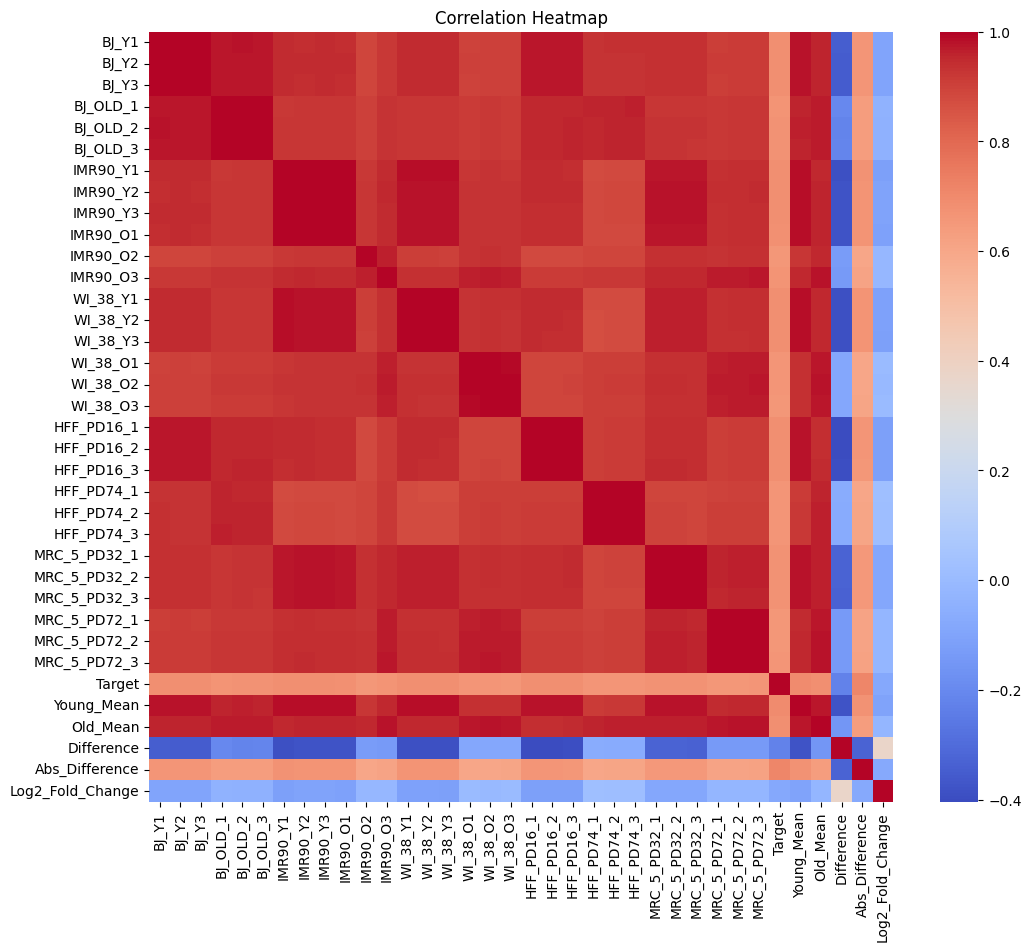

In [90]:
plt.figure(figsize=(12,10))
sns.heatmap(df.select_dtypes(include="number").corr(), cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

    بخش ششم: Data transformation

سؤال 26: آیا ویژگی‌های عددی مقیاس‌های متفاوتی دارند؟
هدف سؤال

بررسی اینکه آیا دامنه مقادیر ویژگی‌های عددی با یکدیگر تفاوت زیادی دارد یا خیر

In [91]:
df.select_dtypes(include="number").describe().loc[["min", "max"]]

,BJ_Y1,BJ_Y2,BJ_Y3,BJ_OLD_1,BJ_OLD_2,BJ_OLD_3,IMR90_Y1,IMR90_Y2,IMR90_Y3,IMR90_O1,...,MRC_5_PD32_3,MRC_5_PD72_1,MRC_5_PD72_2,MRC_5_PD72_3,Target,Young_Mean,Old_Mean,Difference,Abs_Difference,Log2_Fold_Change
min,0.00,0.0,0.00,0.0,0.00,0.00,0.00,0.00,0.0,0.00,...,0.00,0.00,0.00,0.00,0.0,0.000000,0.000000,-6086.282667,0.000000,-5.384784
max,7231.06,10002.3,10995.24,6960.0,11144.14,8353.16,7583.48,10404.22,5997.2,9071.02,...,9898.18,9773.14,9106.14,8846.24,1.0,9023.518667,8592.334667,4729.244000,6086.282667,7.519199


سؤال 27: توزیع ویژگی‌های عددی را بررسی کنید
هدف سؤال

بررسی شکل توزیع داده‌ها و میزان نامتقارن بودن آن‌ها

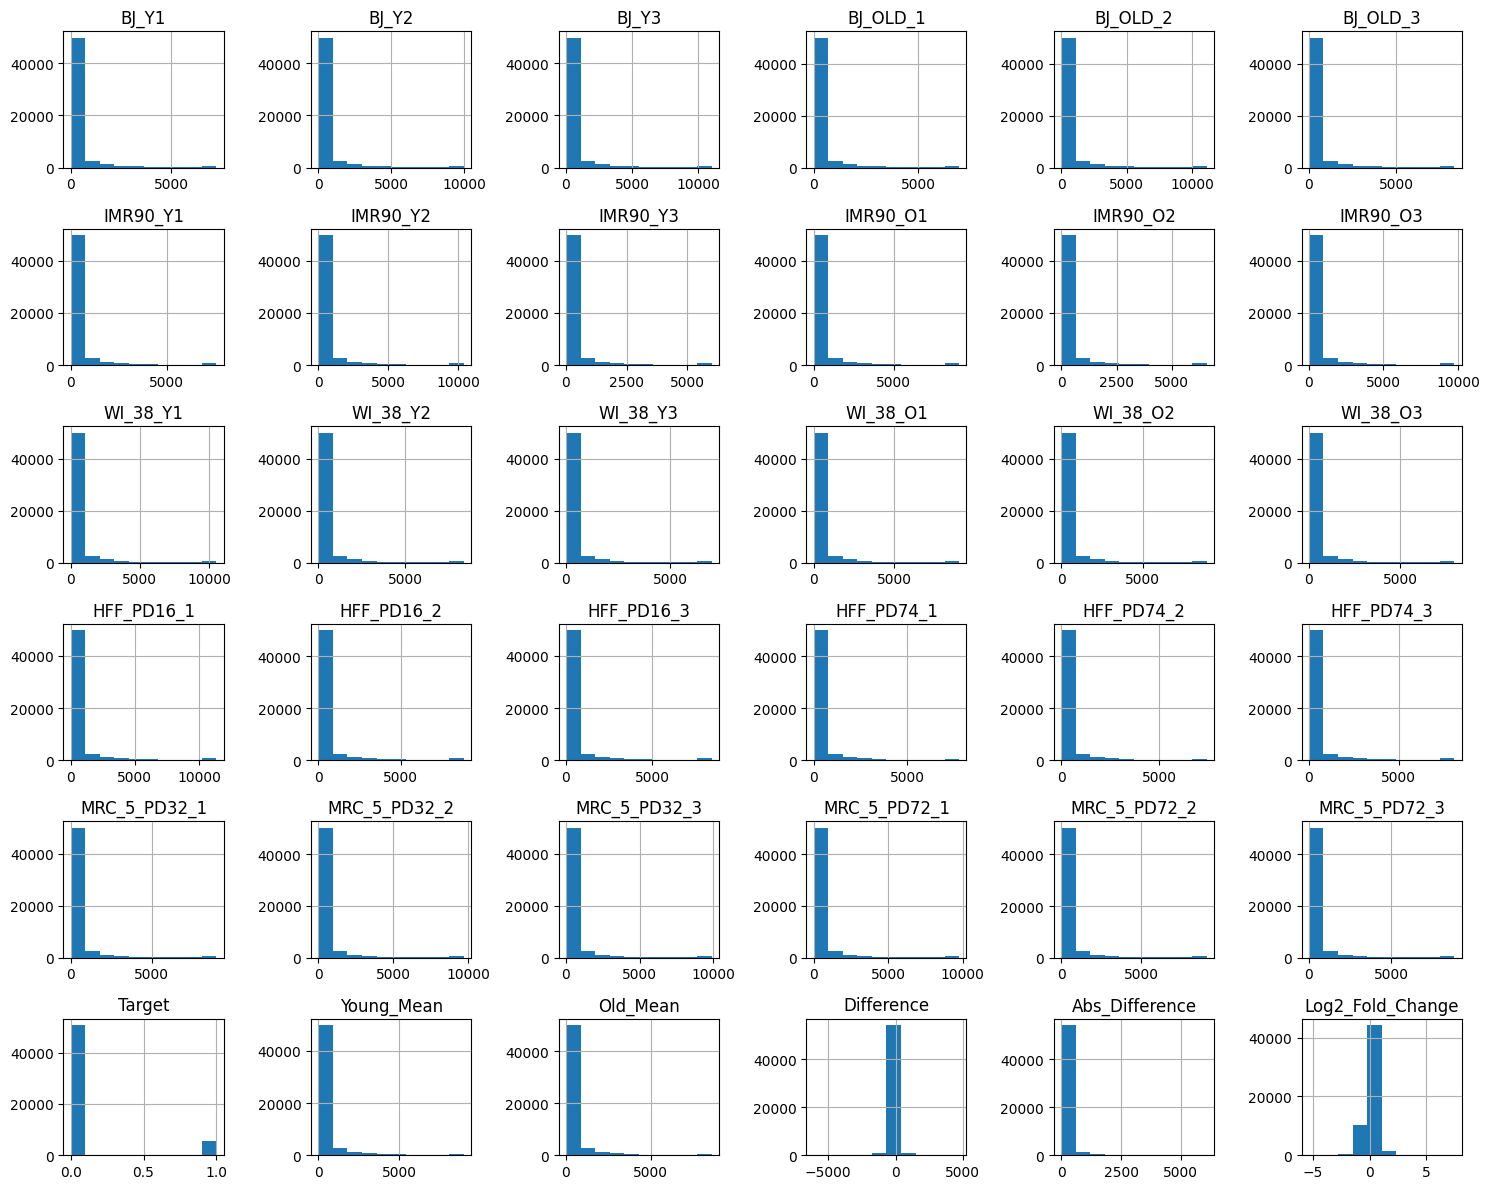

In [92]:
numeric_cols = df.select_dtypes(include="number").columns

df[numeric_cols].hist(figsize=(15,12))
plt.tight_layout()
plt.show()

سؤال 28: آیا ویژگی‌های عددی توزیع نرمال دارند؟

In [93]:
df[numeric_cols].skew().sort_values(ascending=False)

Abs_Difference      6.746395
MRC_5_PD72_2        4.863872
MRC_5_PD32_3        4.847782
MRC_5_PD32_2        4.847044
BJ_OLD_1            4.827984
MRC_5_PD72_1        4.823537
MRC_5_PD72_3        4.821998
BJ_OLD_2            4.817960
BJ_OLD_3            4.809691
MRC_5_PD32_1        4.802912
WI_38_O3            4.789647
WI_38_O1            4.787459
HFF_PD74_2          4.786024
IMR90_O1            4.769865
HFF_PD74_1          4.769837
HFF_PD74_3          4.759121
IMR90_Y3            4.750733
WI_38_O2            4.747535
WI_38_Y1            4.743188
IMR90_Y2            4.740975
WI_38_Y2            4.739898
WI_38_Y3            4.730640
IMR90_Y1            4.726550
HFF_PD16_2          4.723314
HFF_PD16_3          4.719166
HFF_PD16_1          4.713318
BJ_Y1               4.704230
IMR90_O3            4.701108
IMR90_O2            4.689396
BJ_Y2               4.670537
Young_Mean          4.657197
Old_Mean            4.656970
BJ_Y3               4.648221
Target              2.666705
Log2_Fold_Chan

    Normalization & scaling

سؤال 29: Min-Max Scaling را با NumPy پیاده‌سازی کنید



In [95]:
numeric_cols = df.select_dtypes(include="number").columns.drop("Target")

for col in numeric_cols:
    min_val = df[col].min()
    max_val = df[col].max()
    df[col] = (df[col] - min_val) / (max_val - min_val)

df[numeric_cols].head()

,BJ_Y1,BJ_Y2,BJ_Y3,BJ_OLD_1,BJ_OLD_2,BJ_OLD_3,IMR90_Y1,IMR90_Y2,IMR90_Y3,IMR90_O1,...,MRC_5_PD32_2,MRC_5_PD32_3,MRC_5_PD72_1,MRC_5_PD72_2,MRC_5_PD72_3,Young_Mean,Old_Mean,Difference,Abs_Difference,Log2_Fold_Change
0,0.072050,0.075483,0.080944,0.110057,0.103642,0.108582,0.110899,0.106880,0.111719,0.103296,...,0.109309,0.128508,0.139157,0.158574,0.178607,0.093312,0.187516,0.633856,0.126383,0.489788
1,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000008,0.562742,0.000011,0.424512
2,0.109389,0.097178,0.112776,0.100718,0.104001,0.102716,0.154283,0.141385,0.164910,0.160070,...,0.112397,0.121639,0.100889,0.105643,0.115981,0.130599,0.134197,0.560387,0.004173,0.414862
3,0.034711,0.034992,0.035743,0.029167,0.033829,0.031725,0.026769,0.026143,0.031348,0.028001,...,0.026864,0.026368,0.030389,0.029431,0.030069,0.029072,0.029864,0.562206,0.000942,0.414835
4,0.046881,0.048189,0.053114,0.023276,0.024407,0.024661,0.052219,0.045655,0.046688,0.043766,...,0.023982,0.023035,0.014530,0.013178,0.013000,0.040125,0.017915,0.543492,0.034197,0.322086


سؤال 30: Standardization را با NumPy پیاده‌سازی کنید

In [96]:
numeric_cols = df.select_dtypes(include="number").columns.drop("Target")

for col in numeric_cols:
    mean_val = df[col].mean()
    std_val = df[col].std()
    df[col] = (df[col] - mean_val) / std_val

df[numeric_cols].head()

,BJ_Y1,BJ_Y2,BJ_Y3,BJ_OLD_1,BJ_OLD_2,BJ_OLD_3,IMR90_Y1,IMR90_Y2,IMR90_Y3,IMR90_O1,...,MRC_5_PD32_2,MRC_5_PD32_3,MRC_5_PD72_1,MRC_5_PD72_2,MRC_5_PD72_3,Young_Mean,Old_Mean,Difference,Abs_Difference,Log2_Fold_Change
0,0.185550,0.205958,0.240454,0.465614,0.420282,0.453450,0.455518,0.431398,0.466873,0.410462,...,0.463582,0.600266,0.672689,0.816261,0.945420,0.343828,1.032022,2.658654,2.388518,1.875877
1,-0.314447,-0.314974,-0.315669,-0.309106,-0.310031,-0.310291,-0.312605,-0.313389,-0.312972,-0.311694,...,-0.307265,-0.308106,-0.305100,-0.304157,-0.305211,-0.317701,-0.318841,0.080778,-0.280071,0.164318
2,0.444666,0.355683,0.459153,0.399874,0.422812,0.412190,0.756008,0.671846,0.838173,0.807378,...,0.485358,0.551705,0.403797,0.442271,0.506908,0.608177,0.647898,-0.004578,-0.192175,-0.088697
3,-0.073566,-0.073483,-0.070100,-0.103795,-0.071652,-0.087147,-0.127196,-0.131211,-0.094150,-0.115933,...,-0.117820,-0.121719,-0.091568,-0.096212,-0.094662,-0.111595,-0.103749,0.061338,-0.260410,-0.089407
4,0.010887,0.017594,0.049247,-0.145262,-0.138044,-0.136828,0.049080,0.004753,0.012934,-0.005722,...,-0.138143,-0.145285,-0.203007,-0.211047,-0.214184,-0.033238,-0.189830,-0.617038,0.441838,-2.521324


سؤال 31: قبل و بعد از Scaling، Histogram رسم کنید


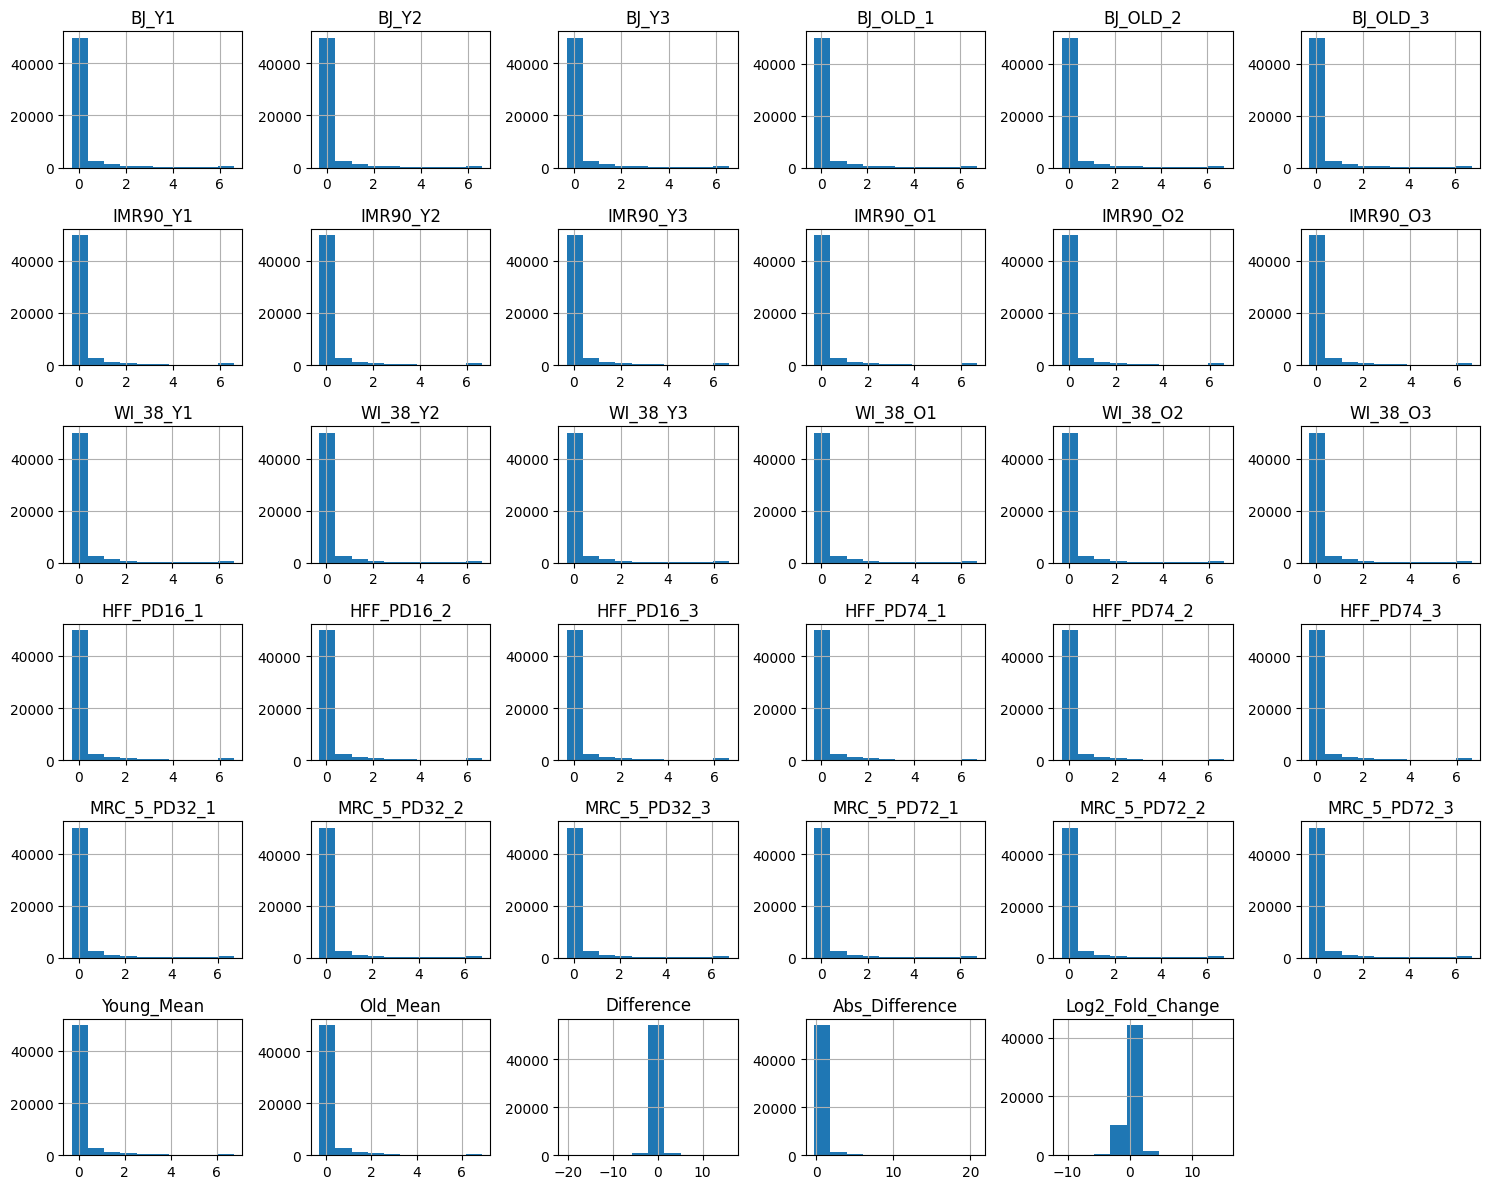

In [97]:
numeric_cols = df.select_dtypes(include="number").columns.drop("Target")

df[numeric_cols].hist(figsize=(15,12))
plt.tight_layout()
plt.show()

سؤال 32: Min-Max و Standardization را مقایسه کنید.
<br>
 کدام برای این پروژه مناسب‌تر است؟

برای این پروژه Standardization بهتره
<br>
چرا؟ چون که داده ها توزیع نرمال ندارند و نامتقارن هستند راست چولگی
<br>
اختلاف مقیاس بین ویژگی ها زیاد است و برخی ژن ها مقادیر بسیار بزرگتری نسبت به سایر ژن ها دارند

    بخش هفتم: Dataset validation

سؤال 33: شکل نهایی دیتاست را گزارش کنید

In [99]:
df.shape

(56299, 39)

سؤال 34: آیا مقدار Null در دیتاست باقی مانده است؟

In [100]:
df.isna().sum().sum()

np.int64(0)

سؤال 35: آیا رکورد تکراری در دیتاست باقی مانده است؟

In [101]:
df.duplicated().sum()

np.int64(0)

سؤال 36: آیا داده‌های پرت مدیریت شده‌اند؟

In [102]:
df.describe().loc[["max"]]

,BJ_Y1,BJ_Y2,BJ_Y3,BJ_OLD_1,BJ_OLD_2,BJ_OLD_3,IMR90_Y1,IMR90_Y2,IMR90_Y3,IMR90_O1,...,MRC_5_PD32_3,MRC_5_PD72_1,MRC_5_PD72_2,MRC_5_PD72_3,Target,Young_Mean,Old_Mean,Difference,Abs_Difference,Log2_Fold_Change
max,6.625119,6.586378,6.554782,6.730129,6.736476,6.723505,6.613726,6.655068,6.667457,6.679437,...,6.760471,6.721421,6.761413,6.69693,1.0,6.771745,6.885386,15.931386,20.8367,15.253881


سؤال 37: آیا نوع داده ستون‌ها مناسب است؟

In [104]:
df.dtypes

ensembl_gene_id         str
external_gene_id        str
gene_biotype            str
BJ_Y1               float64
BJ_Y2               float64
BJ_Y3               float64
BJ_OLD_1            float64
BJ_OLD_2            float64
BJ_OLD_3            float64
IMR90_Y1            float64
IMR90_Y2            float64
IMR90_Y3            float64
IMR90_O1            float64
IMR90_O2            float64
IMR90_O3            float64
WI_38_Y1            float64
WI_38_Y2            float64
WI_38_Y3            float64
WI_38_O1            float64
WI_38_O2            float64
WI_38_O3            float64
HFF_PD16_1          float64
HFF_PD16_2          float64
HFF_PD16_3          float64
HFF_PD74_1          float64
HFF_PD74_2          float64
HFF_PD74_3          float64
MRC_5_PD32_1        float64
MRC_5_PD32_2        float64
MRC_5_PD32_3        float64
MRC_5_PD72_1        float64
MRC_5_PD72_2        float64
MRC_5_PD72_3        float64
Target                int64
Young_Mean          float64
Old_Mean            

    سؤال 38: آیا داده برای KNN مناسب است؟


بله اما با شرط انجام Scaling
<br>

<br>
KNN بر اساس فاصله بین نمونه‌ها عمل می‌کند و به مقیاس ویژگی‌ها حساس است
<br>

 از آنجا که ویژگی‌های بیان ژن دارای مقیاس‌های متفاوت هستند استفاده از Standardization قبل از آموزش مدل مهم است همچنین تعداد زیاد ویژگی‌ها نسبت به تعداد نمونه‌ها ممکن است باعث کاهش عملکرد KNN شود

    سؤال 39: آیا داده برای Logistic Regression مناسب است؟

بله، این دیتاست برای Logistic Regression مناسب است

<br>
<br>
مسئله پروژه یک Binary Classification است و Logistic Regression برای چنین مسئله‌ای مناسب است
<br>
با این حال به دلیل تعداد زیاد ویژگی‌ها بهتر است قبل از مدل‌سازی از Feature Selection یا Regularization استفاده شود
تا از Overfitting جلوگیری شود

    سؤال 40: آیا داده برای Decision Tree مناسب است؟

بله، این دیتاست برای Decision Tree مناسب است.
<br>
Decision Tree نسبت به مقیاس ویژگی‌ها حساس نیست و نیازی به Scaling ندارد همچنین می‌تواند روابط غیرخطی بین ژن‌ها و متغیر هدف را شناسایی کند با این حال به دلیل تعداد زیاد ویژگی‌ها احتمال بیش‌برازش وجود دارد و محدود کردن عمق درخت یا استفاده از Random Forest می‌تواند گزینه بهتری باشد

    سؤال 41: دیتاست نهایی را ذخیره کنید

In [105]:
df.to_csv("gse63577_prepared.csv", index=False)

    سؤال 42: گزارش مدیریتی تهیه کنید
<br>
چه تغییراتی روی داده انجام شد؟
<br>
چه ویژگی‌هایی حذف شدند؟
<br>
چه ویژگی‌هایی ساخته شدند؟
<br>
چه مشکلاتی برطرف شد؟
<br>
آیا داده برای Modeling آماده است؟
<br>

چه تغییراتی روی داده انجام شد؟
<br>

بررسی و مدیریت داده‌های گمشده
<br>

حذف ستون description
<br>

جایگزینی مقادیر گمشده external_gene_id و gene_biotype با مقدار Unknown
<br>

شناسایی داده‌های پرت
<br>

مدیریت داده‌های پرت با روش Winsorization
<br>

ایجاد ستون Target
<br>

بررسی نوع داده ستون‌ها
<br>

بررسی نیاز به Scaling و ارزیابی روش‌های Min-Max و Standardization
<br>
چه ویژگی‌هایی حذف شدند؟
<br>

description
<br>

چه ویژگی‌هایی ساخته شدند؟
<br>



Target: برچسب دودویی ژن‌های مرتبط با پیری (0 = غیرمرتبط، 1 = مرتبط با پیری)
<br>

Young_Mean: میانگین بیان هر ژن در نمونه‌های سلول‌های جوان
<br>

Old_Mean: میانگین بیان هر ژن در نمونه‌های سلول‌های پیر
<br>

Difference: اختلاف میانگین بیان بین سلول‌های پیر و جوان
<br>

Abs_Difference: مقدار مطلق اختلاف بیان
<br>

Log2_Fold_Change: نسبت تغییر بیان ژن بین سلول‌های پیر و جوان به صورت لگاریتم پایه 2
<br>
چه مشکلاتی برطرف شد؟
<br>

داده‌های گمشده
<br>

وجود داده‌های پرت با مقادیر بسیار بزرگ
<br>

وجود نداشتن ستون تارگت
<br>
آیا داده برای Modeling آماده است؟